# K0S-constrained sagitta spatial-distortion DNN

This notebook replaces the direct momentum-scale or additive-curvature fit with a more physical forward model:

\[
A_{\rm side}(\phi,z)
\longrightarrow
r\Delta\phi(r,\phi,z)
\longrightarrow
\text{shifted pseudo-hits}
\longrightarrow
\text{circle refit}
\longrightarrow
(p_T,\phi_{\rm vertex})
\longrightarrow
m_{\pi\pi}.
\]

For each daughter track, the measured helix is propagated through the known \(1.4\ \mathrm{T}\) magnetic field to six fixed TPC radii. A side-specific DNN predicts a common, charge-independent sagitta amplitude:

\[
A_{\rm side}(\phi,z).
\]

The azimuthal spatial correction is

\[
r\Delta\phi(r,\phi,z)
=
A_{\rm side}(\phi,z)\,
g_{\rm sag}(r),
\]

with

\[
g_{\rm sag}(r)
=
4
\frac{(r-r_{\rm in})(r_{\rm out}-r)}
{(r_{\rm out}-r_{\rm in})^2}.
\]

This radial mode is zero at the inner and outer anchor radii and maximal in the middle. It changes track bowing rather than simply rotating every point together.

The DNN has no direct charge, \(p_T\), or \(\eta\) input. It sees spatial detector coordinates:

- \(\sin\phi\);
- \(\cos\phi\);
- \(z\).

Charge and momentum enter only through the trajectory and circle refit. The model recalculates both the corrected curvature and the corrected transverse tangent direction at the production vertex.

The notebook includes:

- smooth daughter-track \(p_T\) reweighting;
- side-specific mass prefits;
- parallel hyperparameter search;
- a main-process preflight trial;
- ensemble training;
- inclusive and \(K^0_S\)-\(p_T\)-binned validation;
- export of \(A(\phi,z)\) and \(r\Delta\phi(r,\phi,z)\);
- conversion to standard prompt-track momentum-scale maps;
- an exact per-track correction function for displaced daughters.


In [1]:
# ============================================================
# Imports and configuration
# ============================================================

from pathlib import Path
from itertools import product
from array import array
import copy
import json
import math
import os
import random
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from scipy.optimize import minimize

try:
    from joblib import Parallel, delayed, parallel_backend
    joblib_available = True
except ImportError:
    joblib_available = False
    print(
        "WARNING: joblib is unavailable; "
        "the search will run sequentially."
    )

try:
    import ROOT as root
except ImportError:
    root = None

seed = 12345

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

csv_file = Path("/media/yoren/T7_Shield/sPHENIX/tracking/csvs/fit_k0s_pp_v1.csv")

work_dir = Path('output/k0s_sagitta_spatial_dnn_cut03/')

work_dir.mkdir(
    parents=True,
    exist_ok=True,
)

checkpoint_dir = (
    work_dir / "checkpoints"
)
checkpoint_dir.mkdir(
    parents=True,
    exist_ok=True,
)

selection_name = "cut03"

training_parity = 0
validation_parity = (
    1 - training_parity
)

pdg_kshort_mass = 0.497611
pion_mass = 0.13957039

magnetic_field_tesla = 1.4

# pT[GeV/c], B[T], R[cm]:
# pT = 0.003 * B * R.
curvature_conversion = 0.003

beam_x_cm = 0.158
beam_y_cm = 0.285
beam_z_cm = 0.0

# Six effective TPC radii. The first and last radii anchor the
# sagitta mode to zero.
pseudo_radii_cm = np.array([
    33.0,
    41.0,
    49.0,
    57.0,
    65.0,
    73.0,
], dtype=np.float64)

sagitta_inner_radius_cm = float(
    pseudo_radii_cm[0]
)

sagitta_outer_radius_cm = float(
    pseudo_radii_cm[-1]
)

z_feature_scale_cm = 105.0

validation_mass_minimum = 0.44
validation_mass_maximum = 0.56

training_mass_half_width_values = [
    0.030,
    0.045,
    0.060,
]

# Smooth single-track pT weighting.
use_smooth_track_pt_reweighting = True

track_pt_weight_minimum = 0.20
track_pt_weight_maximum = 5.00

track_pt_density_number_of_bins = 80
track_pt_density_smoothing_sigma_bins = 2.0

# Tempered inverse density. A value of 0.5 is deliberately less
# aggressive than complete spectrum flattening.
track_pt_weight_power = 0.50

track_pt_density_floor_fraction = 0.05

minimum_track_weight = 0.35
maximum_track_weight = 3.00

pair_weight_combination = (
    "geometric_mean"
)

# Unweighted validation bins in reconstructed K0S pT.
kshort_pt_bin_edges = np.array([
    0.5,
    0.8,
    1.1,
    1.4,
    1.8,
    2.2,
    3.0,
], dtype=np.float64)

requested_cpus = 12
threads_per_worker = 1

parallel_jobs = max(
    1,
    min(
        requested_cpus,
        os.cpu_count() or 1,
    ),
)

search_mode = "random"
maximum_trials_per_side = 24

maximum_search_epochs = 300
search_patience = 35

number_of_ensemble_models = 3
maximum_final_epochs = 1000
final_patience = 60

minimum_candidates_per_side_split = 100

print("PyTorch:", torch.__version__)
print("Available CPUs:", os.cpu_count())
print("Parallel workers:", parallel_jobs)
print("Pseudo radii [cm]:", pseudo_radii_cm)


Welcome to JupyROOT 6.30/06
PyTorch: 2.9.0+cu128
Available CPUs: 16
Parallel workers: 12
Pseudo radii [cm]: [33. 41. 49. 57. 65. 73.]


## Helix propagation and circle refit

The measured daughter helix is propagated from the reconstructed secondary vertex to every pseudo-radius.

In the transverse plane, the propagation convention is

\[
\omega
=
-\frac{q\,0.003B}{p_T},
\]

where \(\omega=d\phi_{\rm momentum}/ds_T\). The longitudinal coordinate is propagated as

\[
z(r_i)
=
z_{\rm vertex}
+
s_{T,i}\sinh\eta.
\]

After applying the spatial shifts, a differentiable algebraic circle fit extracts:

- the corrected circle radius;
- the corrected \(p_T\);
- the corrected tangent direction at the point on the fitted circle closest to the original production vertex.

The original \(\eta\) is retained, so

\[
p_{z,\rm corr}
=
p_{T,\rm corr}\sinh\eta.
\]


In [2]:
# ============================================================
# Vectorized helix propagation to fixed radius
# ============================================================

TWO_PI = 2.0 * math.pi


def wrap_phi_numpy(phi):
    return (
        np.asarray(phi)
        + math.pi
    ) % TWO_PI - math.pi


def propagate_to_radius_numpy(
    x0,
    y0,
    z0,
    phi0,
    eta,
    pt,
    charge,
    target_radius_cm,
):
    """
    Return the first forward intersection of the measured helix
    with a cylinder of radius target_radius_cm.

    Arrays are broadcast together.
    """

    x0 = np.asarray(
        x0,
        dtype=np.float64,
    )

    y0 = np.asarray(
        y0,
        dtype=np.float64,
    )

    z0 = np.asarray(
        z0,
        dtype=np.float64,
    )

    phi0 = np.asarray(
        phi0,
        dtype=np.float64,
    )

    eta = np.asarray(
        eta,
        dtype=np.float64,
    )

    pt = np.asarray(
        pt,
        dtype=np.float64,
    )

    charge = np.asarray(
        charge,
        dtype=np.float64,
    )

    omega = (
        -charge
        * curvature_conversion
        * magnetic_field_tesla
        / np.clip(
            pt,
            1.0e-6,
            None,
        )
    )

    center_x = (
        x0
        - np.sin(phi0) / omega
    )

    center_y = (
        y0
        + np.cos(phi0) / omega
    )

    circle_radius = np.abs(
        1.0 / omega
    )

    center_distance = np.hypot(
        center_x,
        center_y,
    )

    valid = (
        np.isfinite(center_distance)
        & (center_distance > 1.0e-9)
        & (
            target_radius_cm
            <= center_distance
            + circle_radius
        )
        & (
            target_radius_cm
            >= np.abs(
                center_distance
                - circle_radius
            )
        )
    )

    safe_distance = np.where(
        valid,
        center_distance,
        1.0,
    )

    along_center = (
        target_radius_cm ** 2
        - circle_radius ** 2
        + safe_distance ** 2
    ) / (
        2.0 * safe_distance
    )

    height_squared = (
        target_radius_cm ** 2
        - along_center ** 2
    )

    valid &= (
        height_squared
        >= -1.0e-8
    )

    height = np.sqrt(
        np.clip(
            height_squared,
            0.0,
            None,
        )
    )

    unit_x = (
        center_x
        / safe_distance
    )

    unit_y = (
        center_y
        / safe_distance
    )

    base_x = (
        along_center * unit_x
    )

    base_y = (
        along_center * unit_y
    )

    perpendicular_x = -unit_y
    perpendicular_y = unit_x

    intersection_x_a = (
        base_x
        + height
        * perpendicular_x
    )

    intersection_y_a = (
        base_y
        + height
        * perpendicular_y
    )

    intersection_x_b = (
        base_x
        - height
        * perpendicular_x
    )

    intersection_y_b = (
        base_y
        - height
        * perpendicular_y
    )

    def tangent_phi_at_point(
        point_x,
        point_y,
    ):
        sin_phi = (
            omega
            * (
                point_x
                - center_x
            )
        )

        cos_phi = (
            -omega
            * (
                point_y
                - center_y
            )
        )

        return np.arctan2(
            sin_phi,
            cos_phi,
        )

    tangent_phi_a = (
        tangent_phi_at_point(
            intersection_x_a,
            intersection_y_a,
        )
    )

    tangent_phi_b = (
        tangent_phi_at_point(
            intersection_x_b,
            intersection_y_b,
        )
    )

    def forward_path(
        target_phi,
    ):
        positive_rotation = np.mod(
            target_phi - phi0,
            TWO_PI,
        )

        negative_rotation = -np.mod(
            phi0 - target_phi,
            TWO_PI,
        )

        delta_phi = np.where(
            omega > 0.0,
            positive_rotation,
            negative_rotation,
        )

        path = (
            delta_phi / omega
        )

        return np.where(
            path > 1.0e-8,
            path,
            np.inf,
        )

    path_a = forward_path(
        tangent_phi_a
    )

    path_b = forward_path(
        tangent_phi_b
    )

    choose_a = (
        path_a <= path_b
    )

    x = np.where(
        choose_a,
        intersection_x_a,
        intersection_x_b,
    )

    y = np.where(
        choose_a,
        intersection_y_a,
        intersection_y_b,
    )

    tangent_phi = np.where(
        choose_a,
        tangent_phi_a,
        tangent_phi_b,
    )

    transverse_path = np.where(
        choose_a,
        path_a,
        path_b,
    )

    valid &= np.isfinite(
        transverse_path
    )

    z = (
        z0
        + transverse_path
        * np.sinh(eta)
    )

    return {
        "x": np.where(
            valid,
            x,
            np.nan,
        ),
        "y": np.where(
            valid,
            y,
            np.nan,
        ),
        "z": np.where(
            valid,
            z,
            np.nan,
        ),
        "phi_position": np.where(
            valid,
            wrap_phi_numpy(
                np.arctan2(y, x)
            ),
            np.nan,
        ),
        "phi_momentum": np.where(
            valid,
            wrap_phi_numpy(
                tangent_phi
            ),
            np.nan,
        ),
        "transverse_path": np.where(
            valid,
            transverse_path,
            np.nan,
        ),
        "valid": valid,
    }


def build_pseudo_hits_numpy(
    x0,
    y0,
    z0,
    phi0,
    eta,
    pt,
    charge,
):
    all_x = []
    all_y = []
    all_z = []
    all_valid = []

    for radius in pseudo_radii_cm:
        result = (
            propagate_to_radius_numpy(
                x0=x0,
                y0=y0,
                z0=z0,
                phi0=phi0,
                eta=eta,
                pt=pt,
                charge=charge,
                target_radius_cm=float(
                    radius
                ),
            )
        )

        all_x.append(result["x"])
        all_y.append(result["y"])
        all_z.append(result["z"])
        all_valid.append(
            result["valid"]
        )

    return {
        "x": np.stack(
            all_x,
            axis=1,
        ),
        "y": np.stack(
            all_y,
            axis=1,
        ),
        "z": np.stack(
            all_z,
            axis=1,
        ),
        "valid": np.stack(
            all_valid,
            axis=1,
        ),
    }


In [3]:
# ============================================================
# Differentiable circle fit and momentum reconstruction
# ============================================================

def wrap_phi_torch(phi):
    return torch.atan2(
        torch.sin(phi),
        torch.cos(phi),
    )


def fit_circle_torch(
    x,
    y,
    ridge=1.0e-8,
):
    """
    Algebraic circle fit:
      x^2 + y^2 + A*x + B*y + C = 0.

    x and y have shape [batch, number_of_points].
    """

    ones = torch.ones_like(x)

    design = torch.stack(
        [
            x,
            y,
            ones,
        ],
        dim=2,
    )

    target = -(
        x * x
        + y * y
    )[:, :, None]

    design_transpose = (
        design.transpose(
            1,
            2,
        )
    )

    normal_matrix = (
        design_transpose
        @ design
    )

    identity = torch.eye(
        3,
        dtype=x.dtype,
        device=x.device,
    )[None, :, :]

    normal_matrix = (
        normal_matrix
        + ridge * identity
    )

    normal_target = (
        design_transpose
        @ target
    )

    parameters = torch.linalg.solve(
        normal_matrix,
        normal_target,
    )[:, :, 0]

    coefficient_a = (
        parameters[:, 0]
    )

    coefficient_b = (
        parameters[:, 1]
    )

    coefficient_c = (
        parameters[:, 2]
    )

    center_x = (
        -0.5 * coefficient_a
    )

    center_y = (
        -0.5 * coefficient_b
    )

    radius_squared = (
        0.25
        * (
            coefficient_a ** 2
            + coefficient_b ** 2
        )
        - coefficient_c
    )

    radius = torch.sqrt(
        torch.clamp(
            radius_squared,
            min=1.0e-8,
        )
    )

    return {
        "center_x": center_x,
        "center_y": center_y,
        "radius": radius,
    }


def circle_momentum_at_vertex_torch(
    circle,
    charge,
    eta,
    vertex_x,
    vertex_y,
):
    center_x = circle[
        "center_x"
    ]

    center_y = circle[
        "center_y"
    ]

    radius = circle[
        "radius"
    ]

    direction_x = (
        vertex_x - center_x
    )

    direction_y = (
        vertex_y - center_y
    )

    direction_norm = torch.sqrt(
        torch.clamp(
            direction_x ** 2
            + direction_y ** 2,
            min=1.0e-12,
        )
    )

    point_x = (
        center_x
        + radius
        * direction_x
        / direction_norm
    )

    point_y = (
        center_y
        + radius
        * direction_y
        / direction_norm
    )

    # d(phi_momentum)/ds_T = omega = -q/R.
    omega = (
        -charge / radius
    )

    sin_phi = (
        omega
        * (
            point_x - center_x
        )
    )

    cos_phi = (
        -omega
        * (
            point_y - center_y
        )
    )

    phi = torch.atan2(
        sin_phi,
        cos_phi,
    )

    transverse_momentum = (
        curvature_conversion
        * magnetic_field_tesla
        * radius
    )

    px = (
        transverse_momentum
        * torch.cos(phi)
    )

    py = (
        transverse_momentum
        * torch.sin(phi)
    )

    pz = (
        transverse_momentum
        * torch.sinh(eta)
    )

    return {
        "pt": transverse_momentum,
        "phi": phi,
        "px": px,
        "py": py,
        "pz": pz,
        "point_x": point_x,
        "point_y": point_y,
    }


def invariant_mass_torch(
    momentum1,
    momentum2,
    mass1=pion_mass,
    mass2=pion_mass,
):
    energy1 = torch.sqrt(
        torch.sum(
            momentum1 * momentum1,
            dim=1,
        )
        + mass1 ** 2
    )

    energy2 = torch.sqrt(
        torch.sum(
            momentum2 * momentum2,
            dim=1,
        )
        + mass2 ** 2
    )

    total = (
        momentum1 + momentum2
    )

    mass_squared = (
        (energy1 + energy2) ** 2
        - torch.sum(
            total * total,
            dim=1,
        )
    )

    return torch.sqrt(
        torch.clamp(
            mass_squared,
            min=0.0,
        )
    )


In [4]:
# ============================================================
# Geometry closure test with zero spatial correction
# ============================================================

toy_pt = np.array([
    0.5,
    0.8,
    1.0,
    1.5,
    2.5,
    0.5,
    0.8,
    1.0,
    1.5,
    2.5,
])

toy_charge = np.array([
    +1,
    +1,
    +1,
    +1,
    +1,
    -1,
    -1,
    -1,
    -1,
    -1,
], dtype=np.float64)

toy_phi = np.linspace(
    -2.5,
    2.5,
    len(toy_pt),
)

toy_eta = np.linspace(
    -0.8,
    0.8,
    len(toy_pt),
)

toy_hits = build_pseudo_hits_numpy(
    x0=np.full(
        len(toy_pt),
        beam_x_cm,
    ),
    y0=np.full(
        len(toy_pt),
        beam_y_cm,
    ),
    z0=np.full(
        len(toy_pt),
        beam_z_cm,
    ),
    phi0=toy_phi,
    eta=toy_eta,
    pt=toy_pt,
    charge=toy_charge,
)

if not np.all(
    toy_hits["valid"]
):
    raise RuntimeError(
        "Toy closure tracks did not reach "
        "all pseudo-radii."
    )

toy_x = torch.from_numpy(
    toy_hits["x"]
).double()

toy_y = torch.from_numpy(
    toy_hits["y"]
).double()

toy_circle = fit_circle_torch(
    toy_x,
    toy_y,
)

toy_momentum = (
    circle_momentum_at_vertex_torch(
        circle=toy_circle,
        charge=torch.from_numpy(
            toy_charge
        ).double(),
        eta=torch.from_numpy(
            toy_eta
        ).double(),
        vertex_x=torch.full(
            (len(toy_pt),),
            beam_x_cm,
            dtype=torch.float64,
        ),
        vertex_y=torch.full(
            (len(toy_pt),),
            beam_y_cm,
            dtype=torch.float64,
        ),
    )
)

pt_relative_error = (
    toy_momentum["pt"].numpy()
    / toy_pt
    - 1.0
)

phi_error = np.arctan2(
    np.sin(
        toy_momentum[
            "phi"
        ].numpy()
        - toy_phi
    ),
    np.cos(
        toy_momentum[
            "phi"
        ].numpy()
        - toy_phi
    ),
)

print(
    "Maximum zero-correction pT closure:",
    np.max(
        np.abs(
            pt_relative_error
        )
    ),
)

print(
    "Maximum zero-correction phi closure:",
    np.max(
        np.abs(
            phi_error
        )
    ),
)

if (
    np.max(
        np.abs(
            pt_relative_error
        )
    ) > 1.0e-5
    or np.max(
        np.abs(
            phi_error
        )
    ) > 1.0e-5
):
    raise RuntimeError(
        "Pseudo-hit circle-fit closure failed."
    )


Maximum zero-correction pT closure: 1.6690683257714056e-07
Maximum zero-correction phi closure: 1.499477164657037e-08


## Load and preprocess the K0S candidates

The notebook keeps same-side \(K^0_S\) candidates passing the established cuts. Both daughter tracks must reach every pseudo-radius.

The pseudo-hit coordinates are calculated once and written to one compressed NPZ file per side. Parallel grid-search workers load these compact arrays rather than serializing the full pandas DataFrame.


In [5]:
# ============================================================
# Load CSV and apply established selection
# ============================================================

data = pd.read_csv(
    csv_file
)

required_columns = [
    "entry_parity",
    "candidate_mask",
    "same_side",
    "side1",
    "side2",
    "charge1",
    "charge2",
    "px1",
    "py1",
    "pz1",
    "pt1",
    "phi1",
    "eta1",
    "px2",
    "py2",
    "pz2",
    "pt2",
    "phi2",
    "eta2",
    "mass_before",
    "kshort_pt",
    "pca_x",
    "pca_y",
    "pca_z",
    "pass_pion_pid",
    "pass_signed_delta_phi",
    "pass_cut03",
    "pass_cut07",
]

missing_columns = [
    column
    for column in required_columns
    if column not in data.columns
]

if missing_columns:
    raise KeyError(
        "CSV is missing required columns: "
        f"{missing_columns}"
    )

if selection_name == "cut03":
    selection_flag = (
        data["pass_cut03"]
        .astype(bool)
    )
elif selection_name == "cut07":
    selection_flag = (
        data["pass_cut07"]
        .astype(bool)
    )
else:
    raise ValueError(
        "selection_name must be "
        "'cut03' or 'cut07'"
    )

selected = data.loc[
    selection_flag
    & data[
        "pass_pion_pid"
    ].astype(bool)
    & data[
        "pass_signed_delta_phi"
    ].astype(bool)
    & data[
        "same_side"
    ].astype(bool)
    & (
        data["mass_before"]
        >= validation_mass_minimum
    )
    & (
        data["mass_before"]
        <= validation_mass_maximum
    )
].copy()

selected["side"] = (
    selected["side1"]
    .astype(int)
)

print(
    "Rows before pseudo-hit requirement:",
    len(selected),
)


Rows before pseudo-hit requirement: 31427


In [6]:
# ============================================================
# Build pseudo-hits for both daughters
# ============================================================

hits1 = build_pseudo_hits_numpy(
    x0=selected[
        "pca_x"
    ].to_numpy(),
    y0=selected[
        "pca_y"
    ].to_numpy(),
    z0=selected[
        "pca_z"
    ].to_numpy(),
    phi0=selected[
        "phi1"
    ].to_numpy(),
    eta=selected[
        "eta1"
    ].to_numpy(),
    pt=selected[
        "pt1"
    ].to_numpy(),
    charge=selected[
        "charge1"
    ].to_numpy(),
)

hits2 = build_pseudo_hits_numpy(
    x0=selected[
        "pca_x"
    ].to_numpy(),
    y0=selected[
        "pca_y"
    ].to_numpy(),
    z0=selected[
        "pca_z"
    ].to_numpy(),
    phi0=selected[
        "phi2"
    ].to_numpy(),
    eta=selected[
        "eta2"
    ].to_numpy(),
    pt=selected[
        "pt2"
    ].to_numpy(),
    charge=selected[
        "charge2"
    ].to_numpy(),
)

valid_candidate = (
    np.all(
        hits1["valid"],
        axis=1,
    )
    & np.all(
        hits2["valid"],
        axis=1,
    )
)

selected = selected.loc[
    valid_candidate
].copy()

for key in [
    "x",
    "y",
    "z",
]:
    hits1[key] = (
        hits1[key][
            valid_candidate
        ]
    )

    hits2[key] = (
        hits2[key][
            valid_candidate
        ]
    )

print(
    "Rows after pseudo-hit requirement:",
    len(selected),
)

print(
    selected.groupby(
        [
            "side",
            "entry_parity",
        ]
    ).size()
)

for side in [0, 1]:
    for parity in [
        training_parity,
        validation_parity,
    ]:
        count = np.count_nonzero(
            (
                selected["side"]
                == side
            )
            & (
                selected[
                    "entry_parity"
                ] == parity
            )
        )

        if (
            count
            < minimum_candidates_per_side_split
        ):
            raise RuntimeError(
                f"Only {count} candidates "
                f"for side={side}, "
                f"parity={parity}."
            )


Rows after pseudo-hit requirement: 31427
side  entry_parity
0     0               8643
      1               8334
1     0               7266
      1               7184
dtype: int64


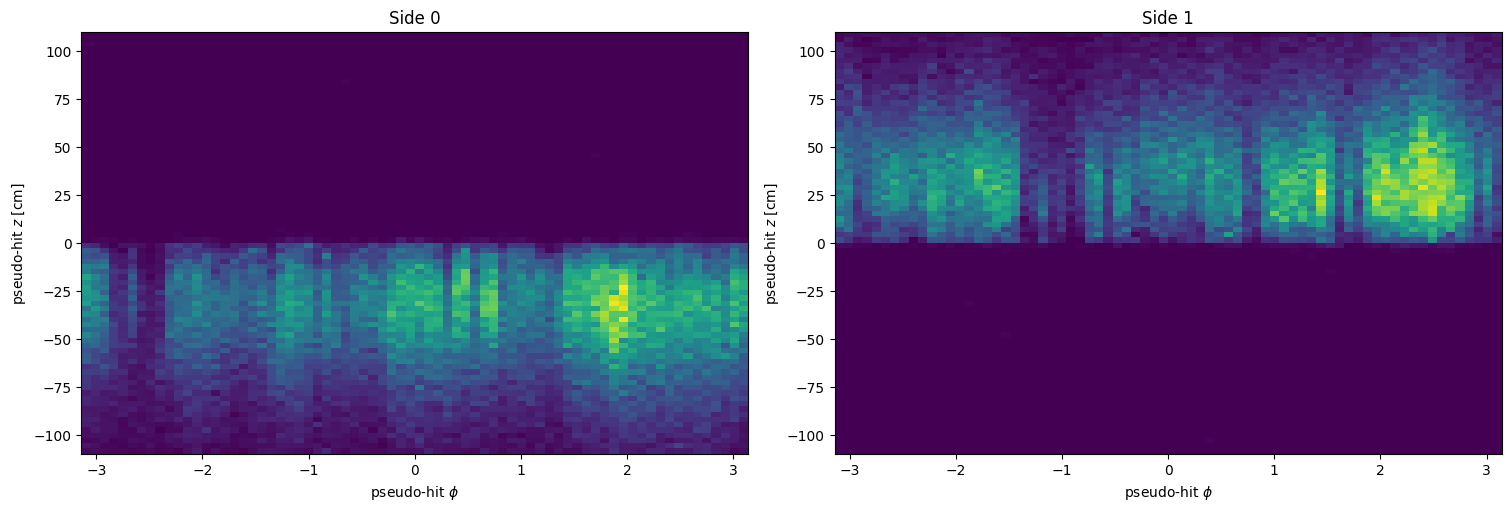

In [7]:
# ============================================================
# Pseudo-hit spatial coverage QA
# ============================================================

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    constrained_layout=True,
)

for side in [0, 1]:
    mask = (
        selected["side"]
        .to_numpy()
        == side
    )

    phi_hits = np.arctan2(
        hits1["y"][mask],
        hits1["x"][mask],
    ).ravel()

    z_hits = (
        hits1["z"][mask]
        .ravel()
    )

    axes[side].hist2d(
        phi_hits,
        z_hits,
        bins=(72, 80),
        range=(
            (-math.pi, math.pi),
            (
                -110.0,
                110.0,
            ),
        ),
    )

    axes[side].set_xlabel(
        r"pseudo-hit $\phi$"
    )

    axes[side].set_ylabel(
        r"pseudo-hit $z$ [cm]"
    )

    axes[side].set_title(
        f"Side {side}"
    )

plt.show()


## Conventional mass prefits

For each side and training mass window, the uncorrected training distribution is fitted with a truncated Gaussian signal plus normalized linear background:

\[
P(m)
=
fG(m;\mu,\sigma)
+
(1-f)B_{\rm linear}(m).
\]

The DNN training keeps fixed:

- the fitted signal fraction;
- the fitted signal width;
- the fitted background slope.

The DNN signal mean is centered at the PDG \(K^0_S\) mass.

A separate broad-window prefit is used to rank every hyperparameter trial on the same validation interval.


In [8]:
# ============================================================
# Truncated-Gaussian plus linear-background mass model
# ============================================================

SQRT_TWO = math.sqrt(2.0)


def normal_cdf_scalar(
    value,
):
    return 0.5 * (
        1.0
        + math.erf(
            float(value)
            / SQRT_TWO
        )
    )


def mass_pdf_numpy(
    mass,
    signal_fraction,
    mean,
    sigma,
    background_slope,
    mass_minimum,
    mass_maximum,
):
    mass = np.asarray(
        mass,
        dtype=np.float64,
    )

    lower_cdf = normal_cdf_scalar(
        (
            mass_minimum - mean
        ) / sigma
    )

    upper_cdf = normal_cdf_scalar(
        (
            mass_maximum - mean
        ) / sigma
    )

    gaussian_normalization = (
        sigma
        * math.sqrt(
            2.0 * math.pi
        )
        * max(
            upper_cdf
            - lower_cdf,
            1.0e-12,
        )
    )

    signal = np.exp(
        -0.5
        * (
            (
                mass - mean
            ) / sigma
        ) ** 2
    ) / gaussian_normalization

    normalized_mass = (
        2.0 * mass
        - mass_maximum
        - mass_minimum
    ) / (
        mass_maximum
        - mass_minimum
    )

    background = np.clip(
        (
            1.0
            + background_slope
            * normalized_mass
        ) / (
            mass_maximum
            - mass_minimum
        ),
        1.0e-12,
        None,
    )

    return (
        signal_fraction
        * signal
        + (
            1.0
            - signal_fraction
        ) * background
    )


def fit_mass_model(
    masses,
    mass_minimum,
    mass_maximum,
):
    masses = np.asarray(
        masses,
        dtype=np.float64,
    )

    masses = masses[
        (
            masses
            >= mass_minimum
        )
        & (
            masses
            <= mass_maximum
        )
    ]

    if len(masses) < 100:
        raise RuntimeError(
            "Too few candidates for "
            "the mass prefit."
        )

    def objective(
        parameters,
    ):
        (
            signal_fraction,
            mean,
            sigma,
            background_slope,
        ) = parameters

        probability = mass_pdf_numpy(
            mass=masses,
            signal_fraction=(
                signal_fraction
            ),
            mean=mean,
            sigma=sigma,
            background_slope=(
                background_slope
            ),
            mass_minimum=(
                mass_minimum
            ),
            mass_maximum=(
                mass_maximum
            ),
        )

        return float(
            -np.sum(
                np.log(
                    np.clip(
                        probability,
                        1.0e-15,
                        None,
                    )
                )
            )
        )

    result = minimize(
        objective,
        x0=[
            0.55,
            0.495,
            0.009,
            0.0,
        ],
        method="L-BFGS-B",
        bounds=[
            (0.05, 0.95),
            (0.475, 0.515),
            (0.003, 0.025),
            (-0.90, 0.90),
        ],
    )

    (
        signal_fraction,
        mean,
        sigma,
        background_slope,
    ) = result.x

    return {
        "signal_fraction": float(
            signal_fraction
        ),
        "raw_peak_mean": float(
            mean
        ),
        "signal_sigma": float(
            sigma
        ),
        "background_slope": float(
            background_slope
        ),
        "success": bool(
            result.success
        ),
        "entries": int(
            len(masses)
        ),
        "mass_minimum": float(
            mass_minimum
        ),
        "mass_maximum": float(
            mass_maximum
        ),
    }


mass_models = {
    0: {},
    1: {},
}

validation_mass_models = {}

for side in [0, 1]:
    training_frame = selected.loc[
        (
            selected["side"]
            == side
        )
        & (
            selected[
                "entry_parity"
            ] == training_parity
        )
    ]

    validation_mass_models[
        side
    ] = fit_mass_model(
        masses=training_frame[
            "mass_before"
        ].to_numpy(),
        mass_minimum=(
            validation_mass_minimum
        ),
        mass_maximum=(
            validation_mass_maximum
        ),
    )

    for half_width in (
        training_mass_half_width_values
    ):
        model = fit_mass_model(
            masses=training_frame[
                "mass_before"
            ].to_numpy(),
            mass_minimum=(
                pdg_kshort_mass
                - half_width
            ),
            mass_maximum=(
                pdg_kshort_mass
                + half_width
            ),
        )

        mass_models[
            side
        ][float(half_width)] = (
            model
        )

        print(
            f"side={side}, "
            f"half-width="
            f"{half_width:.3f}:",
            model,
        )


side=0, half-width=0.030: {'signal_fraction': 0.5355607499792965, 'raw_peak_mean': 0.4986884132270718, 'signal_sigma': 0.00784055216816697, 'background_slope': 0.2571863900633162, 'success': True, 'entries': 6825, 'mass_minimum': 0.467611, 'mass_maximum': 0.527611}
side=0, half-width=0.045: {'signal_fraction': 0.48237010428653193, 'raw_peak_mean': 0.4990643480295547, 'signal_sigma': 0.008379640050629389, 'background_slope': 0.21324859611654629, 'success': True, 'entries': 8177, 'mass_minimum': 0.45261100000000004, 'mass_maximum': 0.5426110000000001}
side=0, half-width=0.060: {'signal_fraction': 0.5711393391222692, 'raw_peak_mean': 0.49929513917008583, 'signal_sigma': 0.01073001294897585, 'background_slope': 0.4176449841306641, 'success': True, 'entries': 8643, 'mass_minimum': 0.437611, 'mass_maximum': 0.5576110000000001}
side=1, half-width=0.030: {'signal_fraction': 0.5451996127013637, 'raw_peak_mean': 0.49839471570144156, 'signal_sigma': 0.00743534071360383, 'background_slope': 0.2365

## Smooth daughter-track \(p_T\) weighting

The training spectrum is steeply falling. To prevent low-\(p_T\) daughters from completely dominating while avoiding unstable tail weights, the notebook estimates a smooth density in \(\log p_T\):

\[
\rho_{\rm side}(\log p_T).
\]

The track weight is

\[
w_{\rm track}(p_T)
\propto
\rho_{\rm side}(\log p_T)^{-1/2}.
\]

The two daughter weights are combined with a geometric mean:

\[
w_{\rm pair}
=
\sqrt{w_1w_2}.
\]

Weights are clipped and normalized to mean one. Validation remains unweighted.


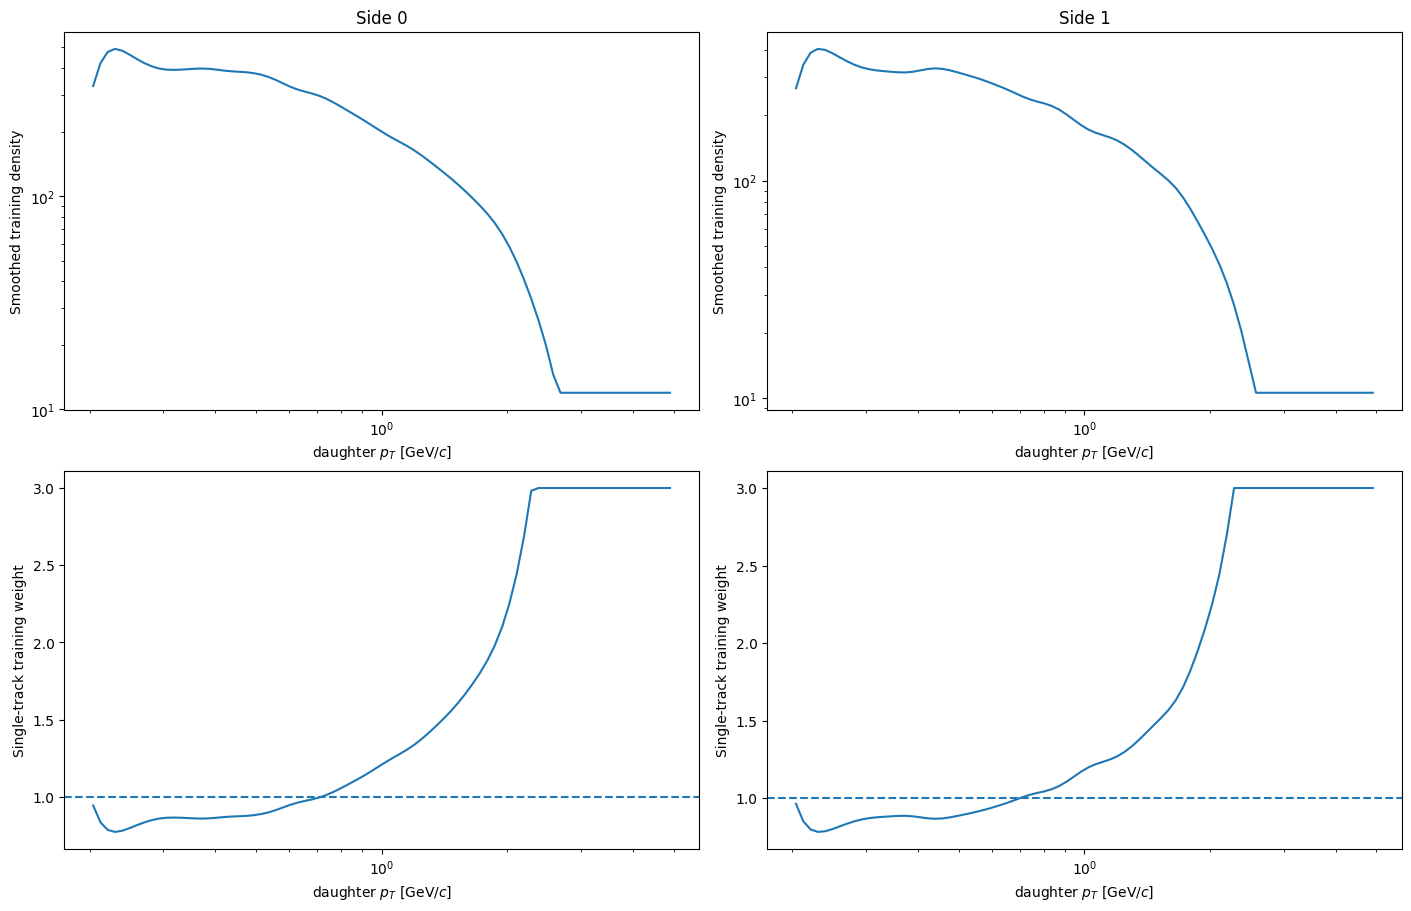

In [9]:
# ============================================================
# Smooth daughter-pT density and pair weights
# ============================================================

def gaussian_kernel_1d(
    sigma_bins,
    truncate=4.0,
):
    radius = max(
        1,
        int(
            math.ceil(
                truncate
                * sigma_bins
            )
        ),
    )

    offsets = np.arange(
        -radius,
        radius + 1,
        dtype=np.float64,
    )

    kernel = np.exp(
        -0.5
        * (
            offsets
            / sigma_bins
        ) ** 2
    )

    kernel /= np.sum(kernel)

    return kernel


def build_track_pt_weight_model(
    frame,
):
    daughter_pt = np.concatenate([
        frame["pt1"].to_numpy(
            dtype=np.float64
        ),
        frame["pt2"].to_numpy(
            dtype=np.float64
        ),
    ])

    daughter_pt = daughter_pt[
        np.isfinite(
            daughter_pt
        )
        & (
            daughter_pt
            >= track_pt_weight_minimum
        )
        & (
            daughter_pt
            <= track_pt_weight_maximum
        )
    ]

    log_edges = np.linspace(
        math.log(
            track_pt_weight_minimum
        ),
        math.log(
            track_pt_weight_maximum
        ),
        track_pt_density_number_of_bins
        + 1,
    )

    log_centers = 0.5 * (
        log_edges[:-1]
        + log_edges[1:]
    )

    counts, _ = np.histogram(
        np.log(daughter_pt),
        bins=log_edges,
    )

    smooth_density = np.convolve(
        counts.astype(
            np.float64
        ),
        gaussian_kernel_1d(
            track_pt_density_smoothing_sigma_bins
        ),
        mode="same",
    )

    positive_density = (
        smooth_density[
            smooth_density > 0
        ]
    )

    reference_density = (
        float(
            np.median(
                positive_density
            )
        )
        if len(
            positive_density
        )
        else 1.0
    )

    density_floor = (
        track_pt_density_floor_fraction
        * max(
            reference_density,
            1.0,
        )
    )

    smooth_density = np.maximum(
        smooth_density,
        density_floor,
    )

    track_weights = (
        reference_density
        / smooth_density
    ) ** track_pt_weight_power

    track_weights = np.clip(
        track_weights,
        minimum_track_weight,
        maximum_track_weight,
    )

    population_weights = np.interp(
        np.log(daughter_pt),
        log_centers,
        track_weights,
        left=track_weights[0],
        right=track_weights[-1],
    )

    normalization = float(
        np.mean(
            population_weights
        )
    )

    if normalization > 0:
        track_weights /= (
            normalization
        )

    track_weights = np.clip(
        track_weights,
        minimum_track_weight,
        maximum_track_weight,
    )

    return {
        "log_pt_centers": (
            log_centers
        ),
        "pt_centers": np.exp(
            log_centers
        ),
        "raw_counts": counts,
        "smooth_density": (
            smooth_density
        ),
        "track_weights": (
            track_weights
        ),
    }


track_pt_weight_models = {}

for side in [0, 1]:
    training_frame = selected.loc[
        (
            selected["side"]
            == side
        )
        & (
            selected[
                "entry_parity"
            ] == training_parity
        )
    ]

    track_pt_weight_models[
        side
    ] = build_track_pt_weight_model(
        training_frame
    )


def evaluate_single_track_weight(
    side,
    pt_values,
):
    pt_values = np.asarray(
        pt_values,
        dtype=np.float64,
    )

    model = track_pt_weight_models[
        int(side)
    ]

    safe_pt = np.clip(
        pt_values,
        track_pt_weight_minimum,
        track_pt_weight_maximum,
    )

    weights = np.interp(
        np.log(safe_pt),
        model[
            "log_pt_centers"
        ],
        model[
            "track_weights"
        ],
        left=model[
            "track_weights"
        ][0],
        right=model[
            "track_weights"
        ][-1],
    )

    if not (
        use_smooth_track_pt_reweighting
    ):
        weights = np.ones_like(
            weights
        )

    return np.clip(
        weights,
        minimum_track_weight,
        maximum_track_weight,
    )


def calculate_pair_weights(
    frame,
    side,
):
    weight1 = (
        evaluate_single_track_weight(
            side,
            frame["pt1"].to_numpy(
                dtype=np.float64
            ),
        )
    )

    weight2 = (
        evaluate_single_track_weight(
            side,
            frame["pt2"].to_numpy(
                dtype=np.float64
            ),
        )
    )

    if (
        pair_weight_combination
        == "geometric_mean"
    ):
        pair_weights = np.sqrt(
            weight1 * weight2
        )
    elif (
        pair_weight_combination
        == "arithmetic_mean"
    ):
        pair_weights = 0.5 * (
            weight1 + weight2
        )
    elif (
        pair_weight_combination
        == "harmonic_mean"
    ):
        pair_weights = (
            2.0
            * weight1
            * weight2
            / np.clip(
                weight1
                + weight2,
                1.0e-12,
                None,
            )
        )
    else:
        raise ValueError(
            "Unknown pair weight "
            f"combination: "
            f"{pair_weight_combination}"
        )

    pair_weights /= float(
        np.mean(pair_weights)
    )

    pair_weights = np.clip(
        pair_weights,
        minimum_track_weight,
        maximum_track_weight,
    )

    return pair_weights.astype(
        np.float32
    )


figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    constrained_layout=True,
)

for side in [0, 1]:
    model = track_pt_weight_models[
        side
    ]

    axes[0, side].plot(
        model["pt_centers"],
        model["smooth_density"],
    )

    axes[0, side].set_xscale(
        "log"
    )

    axes[0, side].set_yscale(
        "log"
    )

    axes[0, side].set_xlabel(
        r"daughter $p_T$ [GeV/$c$]"
    )

    axes[0, side].set_ylabel(
        "Smoothed training density"
    )

    axes[0, side].set_title(
        f"Side {side}"
    )

    axes[1, side].plot(
        model["pt_centers"],
        model["track_weights"],
    )

    axes[1, side].axhline(
        1.0,
        linestyle="--",
    )

    axes[1, side].set_xscale(
        "log"
    )

    axes[1, side].set_xlabel(
        r"daughter $p_T$ [GeV/$c$]"
    )

    axes[1, side].set_ylabel(
        "Single-track training weight"
    )

plt.show()


In [10]:
# ============================================================
# Write compact side-specific NPZ files for workers
# ============================================================

side_npz_files = {}

for side in [0, 1]:
    side_mask = (
        selected["side"]
        .to_numpy()
        == side
    )

    frame = selected.loc[
        side_mask
    ].copy()

    pair_weights = (
        calculate_pair_weights(
            frame,
            side,
        )
    )

    output_file = (
        work_dir
        / f"side{side}_pseudo_hits.npz"
    )

    np.savez_compressed(
        output_file,
        x1=hits1["x"][
            side_mask
        ].astype(np.float32),
        y1=hits1["y"][
            side_mask
        ].astype(np.float32),
        z1=hits1["z"][
            side_mask
        ].astype(np.float32),
        x2=hits2["x"][
            side_mask
        ].astype(np.float32),
        y2=hits2["y"][
            side_mask
        ].astype(np.float32),
        z2=hits2["z"][
            side_mask
        ].astype(np.float32),
        vertex_x=frame[
            "pca_x"
        ].to_numpy(
            dtype=np.float32
        ),
        vertex_y=frame[
            "pca_y"
        ].to_numpy(
            dtype=np.float32
        ),
        vertex_z=frame[
            "pca_z"
        ].to_numpy(
            dtype=np.float32
        ),
        charge1=frame[
            "charge1"
        ].to_numpy(
            dtype=np.float32
        ),
        charge2=frame[
            "charge2"
        ].to_numpy(
            dtype=np.float32
        ),
        eta1=frame[
            "eta1"
        ].to_numpy(
            dtype=np.float32
        ),
        eta2=frame[
            "eta2"
        ].to_numpy(
            dtype=np.float32
        ),
        pt1=frame[
            "pt1"
        ].to_numpy(
            dtype=np.float32
        ),
        pt2=frame[
            "pt2"
        ].to_numpy(
            dtype=np.float32
        ),
        phi1=frame[
            "phi1"
        ].to_numpy(
            dtype=np.float32
        ),
        phi2=frame[
            "phi2"
        ].to_numpy(
            dtype=np.float32
        ),
        mass_before=frame[
            "mass_before"
        ].to_numpy(
            dtype=np.float32
        ),
        kshort_pt=frame[
            "kshort_pt"
        ].to_numpy(
            dtype=np.float32
        ),
        parity=frame[
            "entry_parity"
        ].to_numpy(
            dtype=np.int8
        ),
        pair_weight=pair_weights,
    )

    side_npz_files[
        side
    ] = output_file

    print(
        f"side {side}: wrote "
        f"{len(frame)} candidates to "
        f"{output_file}"
    )


side 0: wrote 16977 candidates to output/k0s_sagitta_spatial_dnn_cut03/side0_pseudo_hits.npz
side 1: wrote 14450 candidates to output/k0s_sagitta_spatial_dnn_cut03/side1_pseudo_hits.npz


## Spatial DNN and sagitta forward model

For each pseudo-hit, the network evaluates

\[
A(\phi_i,z_i).
\]

The actual azimuthal displacement is

\[
r_i\Delta\phi_i
=
A(\phi_i,z_i)g_{\rm sag}(r_i).
\]

The corrected hit azimuth is

\[
\phi_i^{\rm corr}
=
\phi_i
+
\frac{r_i\Delta\phi_i}{r_i}.
\]

The hit radius and \(z\) coordinate are unchanged in this first model.

The same side-specific network acts on both daughter charges. Their different responses arise from their different helix trajectories and the signed tangent reconstructed from the shifted pseudo-hits.


In [11]:
# ============================================================
# Dataset and side-specific spatial network
# ============================================================

class PseudoHitPairDataset(
    Dataset
):
    def __init__(
        self,
        arrays,
        indices,
    ):
        self.x1 = torch.from_numpy(
            arrays["x1"][indices]
        )

        self.y1 = torch.from_numpy(
            arrays["y1"][indices]
        )

        self.z1 = torch.from_numpy(
            arrays["z1"][indices]
        )

        self.x2 = torch.from_numpy(
            arrays["x2"][indices]
        )

        self.y2 = torch.from_numpy(
            arrays["y2"][indices]
        )

        self.z2 = torch.from_numpy(
            arrays["z2"][indices]
        )

        self.vertex_x = torch.from_numpy(
            arrays[
                "vertex_x"
            ][indices]
        )

        self.vertex_y = torch.from_numpy(
            arrays[
                "vertex_y"
            ][indices]
        )

        self.charge1 = torch.from_numpy(
            arrays[
                "charge1"
            ][indices]
        )

        self.charge2 = torch.from_numpy(
            arrays[
                "charge2"
            ][indices]
        )

        self.eta1 = torch.from_numpy(
            arrays[
                "eta1"
            ][indices]
        )

        self.eta2 = torch.from_numpy(
            arrays[
                "eta2"
            ][indices]
        )

        self.pt1 = torch.from_numpy(
            arrays[
                "pt1"
            ][indices]
        )

        self.pt2 = torch.from_numpy(
            arrays[
                "pt2"
            ][indices]
        )

        self.phi1 = torch.from_numpy(
            arrays[
                "phi1"
            ][indices]
        )

        self.phi2 = torch.from_numpy(
            arrays[
                "phi2"
            ][indices]
        )

        self.mass_before = (
            torch.from_numpy(
                arrays[
                    "mass_before"
                ][indices]
            )
        )

        self.kshort_pt = (
            torch.from_numpy(
                arrays[
                    "kshort_pt"
                ][indices]
            )
        )

        self.pair_weight = (
            torch.from_numpy(
                arrays[
                    "pair_weight"
                ][indices]
            )
        )

    def __len__(self):
        return len(
            self.mass_before
        )

    def __getitem__(self, index):
        return {
            "x1": self.x1[index],
            "y1": self.y1[index],
            "z1": self.z1[index],
            "x2": self.x2[index],
            "y2": self.y2[index],
            "z2": self.z2[index],
            "vertex_x": (
                self.vertex_x[index]
            ),
            "vertex_y": (
                self.vertex_y[index]
            ),
            "charge1": (
                self.charge1[index]
            ),
            "charge2": (
                self.charge2[index]
            ),
            "eta1": self.eta1[index],
            "eta2": self.eta2[index],
            "pt1": self.pt1[index],
            "pt2": self.pt2[index],
            "phi1": self.phi1[index],
            "phi2": self.phi2[index],
            "mass_before": (
                self.mass_before[
                    index
                ]
            ),
            "kshort_pt": (
                self.kshort_pt[
                    index
                ]
            ),
            "pair_weight": (
                self.pair_weight[
                    index
                ]
            ),
        }


class SagittaSpatialNetwork(
    nn.Module
):
    def __init__(
        self,
        configuration,
    ):
        super().__init__()

        hidden_width = int(
            configuration[
                "hidden_width"
            ]
        )

        hidden_layers = int(
            configuration[
                "hidden_layers"
            ]
        )

        dropout_probability = float(
            configuration[
                "dropout_probability"
            ]
        )

        layers = []
        input_width = 3

        for _ in range(
            hidden_layers
        ):
            layers.extend([
                nn.Linear(
                    input_width,
                    hidden_width,
                ),
                nn.SiLU(),
                nn.Dropout(
                    dropout_probability
                ),
            ])

            input_width = (
                hidden_width
            )

        self.trunk = nn.Sequential(
            *layers
        )

        self.output = nn.Linear(
            input_width,
            1,
        )

        self.maximum_amplitude_cm = float(
            configuration[
                "maximum_sagitta_amplitude_cm"
            ]
        )

        nn.init.zeros_(
            self.output.weight
        )

        nn.init.zeros_(
            self.output.bias
        )

    def amplitude(
        self,
        phi,
        z,
    ):
        features = torch.stack([
            torch.sin(phi),
            torch.cos(phi),
            z / z_feature_scale_cm,
        ], dim=-1)

        flat_features = (
            features.reshape(
                -1,
                3,
            )
        )

        raw = self.output(
            self.trunk(
                flat_features
            )
        )[:, 0]

        amplitude = (
            self.maximum_amplitude_cm
            * torch.tanh(raw)
        )

        return amplitude.reshape(
            phi.shape
        )


pseudo_radii_tensor = torch.tensor(
    pseudo_radii_cm,
    dtype=torch.float32,
)

sagitta_basis_numpy = (
    4.0
    * (
        pseudo_radii_cm
        - sagitta_inner_radius_cm
    )
    * (
        sagitta_outer_radius_cm
        - pseudo_radii_cm
    )
    / (
        (
            sagitta_outer_radius_cm
            - sagitta_inner_radius_cm
        ) ** 2
    )
)

sagitta_basis_tensor = (
    torch.tensor(
        sagitta_basis_numpy,
        dtype=torch.float32,
    )
)

print(
    "Sagitta radial basis:",
    sagitta_basis_numpy,
)


Sagitta radial basis: [0.   0.64 0.96 0.96 0.64 0.  ]


In [12]:
# ============================================================
# Apply spatial model to one daughter and refit trajectory
# ============================================================

def correct_track_with_spatial_model(
    model,
    x,
    y,
    z,
    charge,
    eta,
    vertex_x,
    vertex_y,
):
    radius = torch.sqrt(
        torch.clamp(
            x * x + y * y,
            min=1.0e-12,
        )
    )

    phi = torch.atan2(
        y,
        x,
    )

    amplitude = model.amplitude(
        phi,
        z,
    )

    radial_basis = (
        sagitta_basis_tensor
        .to(
            x.device,
            dtype=x.dtype,
        )[None, :]
    )

    r_delta_phi = (
        amplitude
        * radial_basis
    )

    corrected_phi = (
        phi
        + r_delta_phi
        / torch.clamp(
            radius,
            min=1.0e-6,
        )
    )

    corrected_x = (
        radius
        * torch.cos(
            corrected_phi
        )
    )

    corrected_y = (
        radius
        * torch.sin(
            corrected_phi
        )
    )

    circle = fit_circle_torch(
        corrected_x,
        corrected_y,
    )

    momentum = (
        circle_momentum_at_vertex_torch(
            circle=circle,
            charge=charge,
            eta=eta,
            vertex_x=vertex_x,
            vertex_y=vertex_y,
        )
    )

    return {
        "amplitude": amplitude,
        "r_delta_phi": (
            r_delta_phi
        ),
        "corrected_x": (
            corrected_x
        ),
        "corrected_y": (
            corrected_y
        ),
        "circle": circle,
        "momentum": momentum,
    }


## Loss and regularization

The primary loss is the signal-plus-background likelihood of the corrected \(K^0_S\) mass.

Regularization includes:

- sagitta-amplitude penalty;
- local smoothness in \(\phi\) and \(z\);
- optional mean-amplitude penalty;
- a soft penalty if the corrected momentum scale leaves a broad physically allowed interval.

The model is initialized at exactly zero distortion.


In [13]:
# ============================================================
# Weighted mass loss and spatial regularization
# ============================================================

def weighted_mean_torch(
    values,
    weights,
):
    weights = torch.clamp(
        weights,
        min=0.0,
    )

    return torch.sum(
        values * weights
    ) / torch.clamp(
        torch.sum(weights),
        min=1.0e-12,
    )


def mass_nll_per_candidate_torch(
    mass,
    configuration,
):
    signal_fraction = float(
        configuration[
            "signal_fraction"
        ]
    )

    sigma = float(
        configuration[
            "signal_sigma"
        ]
    )

    background_slope = float(
        configuration[
            "background_slope"
        ]
    )

    mass_minimum = float(
        configuration[
            "training_mass_minimum"
        ]
    )

    mass_maximum = float(
        configuration[
            "training_mass_maximum"
        ]
    )

    lower_cdf = (
        normal_cdf_scalar(
            (
                mass_minimum
                - pdg_kshort_mass
            ) / sigma
        )
    )

    upper_cdf = (
        normal_cdf_scalar(
            (
                mass_maximum
                - pdg_kshort_mass
            ) / sigma
        )
    )

    normalization = (
        sigma
        * math.sqrt(
            2.0 * math.pi
        )
        * max(
            upper_cdf
            - lower_cdf,
            1.0e-12,
        )
    )

    signal = torch.exp(
        -0.5
        * (
            (
                mass
                - pdg_kshort_mass
            ) / sigma
        ) ** 2
    ) / normalization

    normalized_mass = (
        2.0 * mass
        - mass_maximum
        - mass_minimum
    ) / (
        mass_maximum
        - mass_minimum
    )

    background = torch.clamp(
        (
            1.0
            + background_slope
            * normalized_mass
        ) / (
            mass_maximum
            - mass_minimum
        ),
        min=1.0e-12,
    )

    probability = (
        signal_fraction
        * signal
        + (
            1.0
            - signal_fraction
        ) * background
    )

    return -torch.log(
        torch.clamp(
            probability,
            min=1.0e-12,
        )
    )


def calculate_batch_loss(
    model,
    batch,
    configuration,
):
    corrected1 = (
        correct_track_with_spatial_model(
            model=model,
            x=batch["x1"],
            y=batch["y1"],
            z=batch["z1"],
            charge=batch["charge1"],
            eta=batch["eta1"],
            vertex_x=batch[
                "vertex_x"
            ],
            vertex_y=batch[
                "vertex_y"
            ],
        )
    )

    corrected2 = (
        correct_track_with_spatial_model(
            model=model,
            x=batch["x2"],
            y=batch["y2"],
            z=batch["z2"],
            charge=batch["charge2"],
            eta=batch["eta2"],
            vertex_x=batch[
                "vertex_x"
            ],
            vertex_y=batch[
                "vertex_y"
            ],
        )
    )

    momentum1 = torch.stack([
        corrected1["momentum"]["px"],
        corrected1["momentum"]["py"],
        corrected1["momentum"]["pz"],
    ], dim=1)

    momentum2 = torch.stack([
        corrected2["momentum"]["px"],
        corrected2["momentum"]["py"],
        corrected2["momentum"]["pz"],
    ], dim=1)

    corrected_mass = (
        invariant_mass_torch(
            momentum1,
            momentum2,
        )
    )

    pair_weight = batch[
        "pair_weight"
    ]

    likelihood_loss = (
        weighted_mean_torch(
            mass_nll_per_candidate_torch(
                corrected_mass,
                configuration,
            ),
            pair_weight,
        )
    )

    amplitude_unit_cm = float(
        configuration[
            "amplitude_regularization_unit_cm"
        ]
    )

    amplitude_per_candidate = 0.5 * (
        torch.mean(
            (
                corrected1[
                    "amplitude"
                ] / amplitude_unit_cm
            ) ** 2,
            dim=1,
        )
        + torch.mean(
            (
                corrected2[
                    "amplitude"
                ] / amplitude_unit_cm
            ) ** 2,
            dim=1,
        )
    )

    amplitude_loss = (
        weighted_mean_torch(
            amplitude_per_candidate,
            pair_weight,
        )
    )

    def smoothness_for_track(
        x,
        y,
        z,
        original_amplitude,
    ):
        phi = torch.atan2(
            y,
            x,
        )

        phi_noise = (
            0.01
            * torch.randn_like(
                phi
            )
        )

        z_noise = (
            1.0
            * torch.randn_like(
                z
            )
        )

        perturbed_amplitude = (
            model.amplitude(
                phi + phi_noise,
                z + z_noise,
            )
        )

        return torch.mean(
            (
                (
                    perturbed_amplitude
                    - original_amplitude
                ) / amplitude_unit_cm
            ) ** 2,
            dim=1,
        )

    smoothness_per_candidate = 0.5 * (
        smoothness_for_track(
            batch["x1"],
            batch["y1"],
            batch["z1"],
            corrected1[
                "amplitude"
            ],
        )
        + smoothness_for_track(
            batch["x2"],
            batch["y2"],
            batch["z2"],
            corrected2[
                "amplitude"
            ],
        )
    )

    smoothness_loss = (
        weighted_mean_torch(
            smoothness_per_candidate,
            pair_weight,
        )
    )

    mean_amplitude_per_candidate = 0.5 * (
        torch.mean(
            corrected1[
                "amplitude"
            ],
            dim=1,
        )
        + torch.mean(
            corrected2[
                "amplitude"
            ],
            dim=1,
        )
    )

    mean_amplitude_loss = (
        weighted_mean_torch(
            mean_amplitude_per_candidate,
            pair_weight,
        ) / amplitude_unit_cm
    ) ** 2

    scale1 = (
        corrected1[
            "momentum"
        ]["pt"]
        / torch.clamp(
            batch["pt1"],
            min=1.0e-6,
        )
    )

    scale2 = (
        corrected2[
            "momentum"
        ]["pt"]
        / torch.clamp(
            batch["pt2"],
            min=1.0e-6,
        )
    )

    scale_limit = float(
        configuration[
            "soft_scale_limit"
        ]
    )

    scale_penalty_per_candidate = 0.5 * (
        torch.relu(
            torch.abs(
                scale1 - 1.0
            ) - scale_limit
        ) ** 2
        + torch.relu(
            torch.abs(
                scale2 - 1.0
            ) - scale_limit
        ) ** 2
    )

    scale_penalty = (
        weighted_mean_torch(
            scale_penalty_per_candidate,
            pair_weight,
        )
    )

    total_loss = (
        likelihood_loss
        + float(
            configuration[
                "amplitude_penalty"
            ]
        ) * amplitude_loss
        + float(
            configuration[
                "smoothness_penalty"
            ]
        ) * smoothness_loss
        + float(
            configuration[
                "mean_amplitude_penalty"
            ]
        ) * mean_amplitude_loss
        + float(
            configuration[
                "scale_penalty"
            ]
        ) * scale_penalty
    )

    return total_loss


In [14]:
# ============================================================
# Unweighted validation evaluation
# ============================================================

def peak_metrics(
    values,
):
    values = np.asarray(
        values,
        dtype=np.float64,
    )

    core = values[
        (
            values >= 0.47
        )
        & (
            values <= 0.53
        )
    ]

    return {
        "mean": (
            float(np.mean(core))
            if len(core)
            else np.nan
        ),
        "width": (
            float(
                np.std(
                    core,
                    ddof=1,
                )
            )
            if len(core) > 1
            else np.nan
        ),
        "entries": int(
            len(core)
        ),
    }


@torch.no_grad()
def evaluate_model(
    model,
    loader,
    configuration,
    validation_mass_model,
):
    model.eval()

    mass_before_values = []
    mass_after_values = []

    scale_values = []
    phi_shift_values = []
    amplitude_values = []

    for batch in loader:
        corrected1 = (
            correct_track_with_spatial_model(
                model,
                batch["x1"],
                batch["y1"],
                batch["z1"],
                batch["charge1"],
                batch["eta1"],
                batch["vertex_x"],
                batch["vertex_y"],
            )
        )

        corrected2 = (
            correct_track_with_spatial_model(
                model,
                batch["x2"],
                batch["y2"],
                batch["z2"],
                batch["charge2"],
                batch["eta2"],
                batch["vertex_x"],
                batch["vertex_y"],
            )
        )

        momentum1 = torch.stack([
            corrected1[
                "momentum"
            ]["px"],
            corrected1[
                "momentum"
            ]["py"],
            corrected1[
                "momentum"
            ]["pz"],
        ], dim=1)

        momentum2 = torch.stack([
            corrected2[
                "momentum"
            ]["px"],
            corrected2[
                "momentum"
            ]["py"],
            corrected2[
                "momentum"
            ]["pz"],
        ], dim=1)

        mass_after = (
            invariant_mass_torch(
                momentum1,
                momentum2,
            )
        )

        mass_before_values.append(
            batch[
                "mass_before"
            ].numpy()
        )

        mass_after_values.append(
            mass_after.numpy()
        )

        scale_values.append(
            torch.cat([
                corrected1[
                    "momentum"
                ]["pt"]
                / batch["pt1"],
                corrected2[
                    "momentum"
                ]["pt"]
                / batch["pt2"],
            ]).numpy()
        )

        phi_shift_values.append(
            torch.cat([
                wrap_phi_torch(
                    corrected1[
                        "momentum"
                    ]["phi"]
                    - batch["phi1"]
                ),
                wrap_phi_torch(
                    corrected2[
                        "momentum"
                    ]["phi"]
                    - batch["phi2"]
                ),
            ]).numpy()
        )

        amplitude_values.append(
            torch.cat([
                corrected1[
                    "amplitude"
                ].reshape(-1),
                corrected2[
                    "amplitude"
                ].reshape(-1),
            ]).numpy()
        )

    mass_before_values = (
        np.concatenate(
            mass_before_values
        )
    )

    mass_after_values = (
        np.concatenate(
            mass_after_values
        )
    )

    scale_values = np.concatenate(
        scale_values
    )

    phi_shift_values = (
        np.concatenate(
            phi_shift_values
        )
    )

    amplitude_values = (
        np.concatenate(
            amplitude_values
        )
    )

    before_metrics = peak_metrics(
        mass_before_values
    )

    after_metrics = peak_metrics(
        mass_after_values
    )

    probability = mass_pdf_numpy(
        mass=mass_after_values,
        signal_fraction=(
            validation_mass_model[
                "signal_fraction"
            ]
        ),
        mean=pdg_kshort_mass,
        sigma=validation_mass_model[
            "signal_sigma"
        ],
        background_slope=(
            validation_mass_model[
                "background_slope"
            ]
        ),
        mass_minimum=(
            validation_mass_minimum
        ),
        mass_maximum=(
            validation_mass_maximum
        ),
    )

    validation_nll = float(
        -np.mean(
            np.log(
                np.clip(
                    probability,
                    1.0e-15,
                    None,
                )
            )
        )
    )

    mean_pull_mev = (
        1000.0
        * abs(
            after_metrics["mean"]
            - pdg_kshort_mass
        )
        if np.isfinite(
            after_metrics["mean"]
        )
        else 1.0e6
    )

    width_ratio = (
        after_metrics["width"]
        / before_metrics["width"]
        if (
            np.isfinite(
                after_metrics["width"]
            )
            and np.isfinite(
                before_metrics["width"]
            )
            and before_metrics[
                "width"
            ] > 0
        )
        else 1.0e6
    )

    maximum_amplitude = float(
        configuration[
            "maximum_sagitta_amplitude_cm"
        ]
    )

    boundary_fraction = float(
        np.mean(
            np.abs(
                amplitude_values
            )
            >= 0.90
            * maximum_amplitude
        )
    )

    maximum_scale_deviation = float(
        np.max(
            np.abs(
                scale_values - 1.0
            )
        )
    )

    maximum_phi_shift = float(
        np.max(
            np.abs(
                phi_shift_values
            )
        )
    )

    score = (
        validation_nll
        + 0.25 * mean_pull_mev
        + 2.0 * max(
            0.0,
            width_ratio - 1.0,
        )
        + 1.0 * boundary_fraction
        + 2.0 * max(
            0.0,
            maximum_scale_deviation
            - 0.15,
        )
        + 2.0 * max(
            0.0,
            maximum_phi_shift
            - 0.05,
        )
    )

    return {
        "score": float(score),
        "validation_nll": (
            validation_nll
        ),
        "mean_before": (
            before_metrics["mean"]
        ),
        "mean_after": (
            after_metrics["mean"]
        ),
        "width_before": (
            before_metrics["width"]
        ),
        "width_after": (
            after_metrics["width"]
        ),
        "width_ratio": float(
            width_ratio
        ),
        "scale_min": float(
            np.min(scale_values)
        ),
        "scale_max": float(
            np.max(scale_values)
        ),
        "phi_shift_min": float(
            np.min(
                phi_shift_values
            )
        ),
        "phi_shift_max": float(
            np.max(
                phi_shift_values
            )
        ),
        "amplitude_min": float(
            np.min(
                amplitude_values
            )
        ),
        "amplitude_max": float(
            np.max(
                amplitude_values
            )
        ),
        "boundary_fraction": (
            boundary_fraction
        ),
        "mass_before": (
            mass_before_values
        ),
        "mass_after": (
            mass_after_values
        ),
    }


In [15]:
# ============================================================
# Train one side-specific model
# ============================================================

def configure_worker_threads(
    number_of_threads=1,
):
    os.environ[
        "OMP_NUM_THREADS"
    ] = str(
        number_of_threads
    )

    os.environ[
        "MKL_NUM_THREADS"
    ] = str(
        number_of_threads
    )

    os.environ[
        "OPENBLAS_NUM_THREADS"
    ] = str(
        number_of_threads
    )

    torch.set_num_threads(
        number_of_threads
    )

    try:
        torch.set_num_interop_threads(
            1
        )
    except RuntimeError:
        pass


def train_one_model(
    side,
    configuration,
    model_seed,
    save_checkpoint=None,
):
    configure_worker_threads(
        threads_per_worker
    )

    random.seed(model_seed)
    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    arrays = np.load(
        side_npz_files[side]
    )

    training_indices = np.flatnonzero(
        (
            arrays["parity"]
            == training_parity
        )
        & (
            arrays[
                "mass_before"
            ]
            >= configuration[
                "training_mass_minimum"
            ]
        )
        & (
            arrays[
                "mass_before"
            ]
            <= configuration[
                "training_mass_maximum"
            ]
        )
    )

    validation_indices = (
        np.flatnonzero(
            arrays["parity"]
            == validation_parity
        )
    )

    training_dataset = (
        PseudoHitPairDataset(
            arrays,
            training_indices,
        )
    )

    validation_dataset = (
        PseudoHitPairDataset(
            arrays,
            validation_indices,
        )
    )

    if len(training_dataset) == 0:
        raise RuntimeError(
            "No training candidates "
            "after mass-window selection."
        )

    training_loader = DataLoader(
        training_dataset,
        batch_size=min(
            int(
                configuration[
                    "batch_size"
                ]
            ),
            len(training_dataset),
        ),
        shuffle=True,
        drop_last=False,
        num_workers=0,
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=min(
            max(
                int(
                    configuration[
                        "batch_size"
                    ]
                ),
                512,
            ),
            len(validation_dataset),
        ),
        shuffle=False,
        drop_last=False,
        num_workers=0,
    )

    model = SagittaSpatialNetwork(
        configuration
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(
            configuration[
                "learning_rate"
            ]
        ),
        weight_decay=float(
            configuration[
                "weight_decay"
            ]
        ),
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=max(
                5,
                int(
                    configuration[
                        "patience"
                    ]
                ) // 4,
            ),
            min_lr=1.0e-5,
        )
    )

    best_state = copy.deepcopy(
        model.state_dict()
    )

    best_score = np.inf
    best_epoch = -1
    stale_epochs = 0

    for epoch in range(
        int(
            configuration[
                "maximum_epochs"
            ]
        )
    ):
        model.train()

        for batch in training_loader:
            optimizer.zero_grad()

            loss = calculate_batch_loss(
                model,
                batch,
                configuration,
            )

            if not torch.isfinite(
                loss
            ):
                raise FloatingPointError(
                    "Non-finite training loss"
                )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=5.0,
            )

            optimizer.step()

        evaluation = evaluate_model(
            model=model,
            loader=validation_loader,
            configuration=(
                configuration
            ),
            validation_mass_model=(
                validation_mass_models[
                    side
                ]
            ),
        )

        scheduler.step(
            evaluation["score"]
        )

        if (
            evaluation["score"]
            < best_score - 1.0e-5
        ):
            best_score = (
                evaluation["score"]
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_epoch = epoch
            stale_epochs = 0
        else:
            stale_epochs += 1

        if (
            stale_epochs
            >= int(
                configuration[
                    "patience"
                ]
            )
        ):
            break

    model.load_state_dict(
        best_state
    )

    final_evaluation = (
        evaluate_model(
            model=model,
            loader=validation_loader,
            configuration=(
                configuration
            ),
            validation_mass_model=(
                validation_mass_models[
                    side
                ]
            ),
        )
    )

    if save_checkpoint is not None:
        torch.save(
            {
                "state_dict": (
                    model.state_dict()
                ),
                "configuration": (
                    configuration
                ),
                "model_seed": (
                    model_seed
                ),
                "best_epoch": (
                    best_epoch
                ),
                "validation": {
                    key: value
                    for key, value
                    in final_evaluation.items()
                    if key
                    not in {
                        "mass_before",
                        "mass_after",
                    }
                },
            },
            save_checkpoint,
        )

    return {
        key: value
        for key, value
        in final_evaluation.items()
        if key
        not in {
            "mass_before",
            "mass_after",
        }
    } | {
        "best_epoch": int(
            best_epoch
        ),
        "training_candidates": int(
            len(training_dataset)
        ),
        "validation_candidates": int(
            len(validation_dataset)
        ),
    }


## Parallel hyperparameter search

The full Cartesian product is large, so the default is a reproducible random subset.

The search varies:

- training mass window;
- network width, depth, and dropout;
- batch size;
- learning rate and weight decay;
- maximum sagitta amplitude;
- amplitude, smoothness, mean, and scale penalties.

A single preflight trial runs in the main process before parallel execution. This exposes ordinary data or geometry errors directly.


In [16]:
# ============================================================
# Search-space construction
# ============================================================

search_space = {
    "training_mass_half_width": [
        0.030,
        0.045,
        0.060,
    ],
    "hidden_width": [
        8,
        16,
        24,
        32,
    ],
    "hidden_layers": [
        1,
        2,
        3,
    ],
    "dropout_probability": [
        0.0,
        0.05,
        0.10,
    ],
    "batch_size": [
        128,
        256,
        512,
    ],
    "learning_rate": [
        3.0e-4,
        1.0e-3,
        2.0e-3,
    ],
    "weight_decay": [
        2.0e-4,
        1.0e-3,
        5.0e-3,
    ],
    "maximum_sagitta_amplitude_cm": [
        0.05,
        0.10,
        0.20,
    ],
    "amplitude_penalty": [
        0.01,
        0.05,
        0.20,
    ],
    "smoothness_penalty": [
        0.05,
        0.20,
        1.00,
    ],
    "mean_amplitude_penalty": [
        0.0,
        0.01,
        0.05,
    ],
    "scale_penalty": [
        1.0,
        5.0,
    ],
}

fixed_parameters = {
    "maximum_epochs": (
        maximum_search_epochs
    ),
    "patience": search_patience,
    "amplitude_regularization_unit_cm": (
        0.10
    ),
    "soft_scale_limit": 0.15,
}

search_keys = list(
    search_space
)

all_configurations = [
    dict(
        zip(
            search_keys,
            values,
        )
    )
    for values in product(
        *[
            search_space[key]
            for key in search_keys
        ]
    )
]

print(
    "Full Cartesian grid size:",
    len(all_configurations),
)

if search_mode == "random":
    generator = (
        np.random.default_rng(
            seed
        )
    )

    chosen_indices = generator.choice(
        len(all_configurations),
        size=min(
            maximum_trials_per_side,
            len(all_configurations),
        ),
        replace=False,
    )

    base_configurations = [
        all_configurations[index]
        for index in chosen_indices
    ]
elif search_mode == "full_grid":
    base_configurations = (
        all_configurations
    )
else:
    raise ValueError(
        "search_mode must be "
        "'random' or 'full_grid'"
    )

side_configurations = {
    0: [],
    1: [],
}

for side in [0, 1]:
    for (
        trial_id,
        base_configuration,
    ) in enumerate(
        base_configurations
    ):
        configuration = copy.deepcopy(
            base_configuration
        )

        half_width = float(
            configuration[
                "training_mass_half_width"
            ]
        )

        mass_model = (
            mass_models[
                side
            ][half_width]
        )

        configuration.update(
            fixed_parameters
        )

        configuration.update({
            "trial_id": trial_id,
            "side": side,
            "training_mass_minimum": (
                pdg_kshort_mass
                - half_width
            ),
            "training_mass_maximum": (
                pdg_kshort_mass
                + half_width
            ),
            "signal_fraction": (
                mass_model[
                    "signal_fraction"
                ]
            ),
            "signal_sigma": (
                mass_model[
                    "signal_sigma"
                ]
            ),
            "background_slope": (
                mass_model[
                    "background_slope"
                ]
            ),
        })

        side_configurations[
            side
        ].append(
            configuration
        )

print(
    "Trials per side:",
    len(base_configurations),
)


Full Cartesian grid size: 472392
Trials per side: 24


In [17]:
# ============================================================
# Preflight and parallel search
# ============================================================

def run_search_trial(
    side,
    configuration,
):
    started = time.time()

    trial_id = int(
        configuration[
            "trial_id"
        ]
    )

    model_seed = (
        seed
        + 100000 * side
        + trial_id
    )

    try:
        metrics = train_one_model(
            side=side,
            configuration=(
                configuration
            ),
            model_seed=model_seed,
        )

        return {
            "success": True,
            "elapsed_seconds": (
                time.time()
                - started
            ),
            **configuration,
            **metrics,
        }

    except Exception as error:
        return {
            "success": False,
            "side": side,
            "trial_id": trial_id,
            "score": np.nan,
            "validation_nll": np.nan,
            "error": repr(error),
            "traceback": (
                traceback.format_exc()
            ),
        }


search_tasks = [
    (side, configuration)
    for side in [0, 1]
    for configuration in (
        side_configurations[side]
    )
]

print(
    "Total trials:",
    len(search_tasks),
)

preflight_side, preflight_configuration = (
    search_tasks[0]
)

print(
    "Preflight:",
    f"side={preflight_side}, "
    f"trial="
    f"{preflight_configuration['trial_id']}",
)

preflight_result = run_search_trial(
    preflight_side,
    preflight_configuration,
)

if not preflight_result[
    "success"
]:
    print(
        preflight_result[
            "error"
        ]
    )

    print(
        preflight_result[
            "traceback"
        ]
    )

    raise RuntimeError(
        "Preflight trial failed."
    )

print(
    "Preflight score:",
    preflight_result["score"],
)

if (
    joblib_available
    and parallel_jobs > 1
):
    with parallel_backend(
        "loky",
        inner_max_num_threads=(
            threads_per_worker
        ),
    ):
        search_results = Parallel(
            n_jobs=parallel_jobs,
            verbose=10,
            batch_size=1,
        )(
            delayed(
                run_search_trial
            )(
                side,
                configuration,
            )
            for (
                side,
                configuration,
            ) in search_tasks
        )
else:
    search_results = [
        run_search_trial(
            side,
            configuration,
        )
        for (
            side,
            configuration,
        ) in search_tasks
    ]

search_results_frame = pd.DataFrame(
    search_results
)

search_results_file = (
    work_dir
    / "grid_search_results.csv"
)

search_results_frame.to_csv(
    search_results_file,
    index=False,
)

successful = (
    search_results_frame.loc[
        search_results_frame[
            "success"
        ].astype(bool)
    ].copy()
)

failed = (
    search_results_frame.loc[
        ~search_results_frame[
            "success"
        ].astype(bool)
    ].copy()
)

print(
    "Successful trials:",
    len(successful),
)

print(
    "Failed trials:",
    len(failed),
)

if len(failed):
    display(
        failed[
            [
                "side",
                "trial_id",
                "error",
            ]
        ].head(20)
    )

    print(
        failed.iloc[0][
            "traceback"
        ]
    )

if len(successful) == 0:
    raise RuntimeError(
        "All trials failed."
    )

for side in [0, 1]:
    side_successful = (
        successful.loc[
            successful["side"]
            == side
        ]
        .sort_values("score")
    )

    print(
        f"Top side {side} trials:"
    )

    display(
        side_successful.head(10)
        [[
            "trial_id",
            "score",
            "validation_nll",
            "mean_after",
            "width_ratio",
            "scale_min",
            "scale_max",
            "phi_shift_min",
            "phi_shift_max",
            "amplitude_min",
            "amplitude_max",
            "boundary_fraction",
            "training_mass_half_width",
            "hidden_width",
            "hidden_layers",
            "learning_rate",
            "weight_decay",
            "maximum_sagitta_amplitude_cm",
            "amplitude_penalty",
            "smoothness_penalty",
            "mean_amplitude_penalty",
            "scale_penalty",
            "best_epoch",
        ]]
    )


Total trials: 48
Preflight: side=0, trial=0
Preflight score: -1.8999501498511386


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   33.5s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:  1.4min
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:  2.1min
[Parallel(n_jobs=12)]: Done  30 out of  48 | elapsed:  3.5min remaining:  2.1min
[Parallel(n_jobs=12)]: Done  35 out of  48 | elapsed:  4.2min remaining:  1.6min
[Parallel(n_jobs=12)]: Done  40 out of  48 | elapsed:  4.5min remaining:   54.5s
[Parallel(n_jobs=12)]: Done  45 out of  48 | elapsed:  5.0min remaining:   19.8s


Successful trials: 48
Failed trials: 0
Top side 0 trials:


[Parallel(n_jobs=12)]: Done  48 out of  48 | elapsed:  5.7min finished


,trial_id,score,validation_nll,mean_after,width_ratio,scale_min,scale_max,phi_shift_min,phi_shift_max,amplitude_min,...,hidden_width,hidden_layers,learning_rate,weight_decay,maximum_sagitta_amplitude_cm,amplitude_penalty,smoothness_penalty,mean_amplitude_penalty,scale_penalty,best_epoch
8,8,-1.900300,-2.444856,0.499788,0.995358,0.905138,1.116336,-0.011458,0.007706,-0.100000,...,32,3,0.002,0.0010,0.10,0.05,0.05,0.01,1.0,12
0,0,-1.899950,-2.445542,0.499793,0.994266,0.923858,1.091545,-0.005191,0.009819,-0.021145,...,32,3,0.001,0.0050,0.10,0.20,0.20,0.05,5.0,41
1,1,-1.899149,-2.445134,0.499795,0.993805,0.918031,1.103702,-0.009562,0.009068,-0.042160,...,24,3,0.002,0.0010,0.20,0.05,0.05,0.01,5.0,10
17,17,-1.899059,-2.444180,0.499791,0.996275,0.909804,1.114769,-0.011282,0.006335,-0.193724,...,24,3,0.001,0.0050,0.20,0.05,1.00,0.05,1.0,10
6,6,-1.898413,-2.443998,0.499793,0.994920,0.909989,1.131087,-0.012469,0.004578,-0.199848,...,8,2,0.001,0.0010,0.20,0.05,0.05,0.05,5.0,73
19,19,-1.897669,-2.444013,0.499792,0.997070,0.914610,1.111265,-0.010308,0.004994,-0.050000,...,16,2,0.001,0.0002,0.05,0.01,0.05,0.05,1.0,26
10,10,-1.897281,-2.444400,0.499799,0.996661,0.926891,1.085751,-0.008817,0.006750,-0.198635,...,32,2,0.002,0.0002,0.20,0.05,1.00,0.01,5.0,5
20,20,-1.895712,-2.443403,0.499802,0.996697,0.928053,1.091428,-0.008845,0.004771,-0.166589,...,24,3,0.001,0.0002,0.20,0.05,1.00,0.05,1.0,87
16,16,-1.893893,-2.441139,0.499800,0.998552,0.936662,1.072254,-0.007584,0.001988,-0.185824,...,24,3,0.001,0.0002,0.20,0.05,1.00,0.05,1.0,16
22,22,-1.893564,-2.444296,0.499813,0.994637,0.896515,1.129828,-0.012547,0.007004,-0.100000,...,24,1,0.001,0.0010,0.10,0.05,0.20,0.05,1.0,24


Top side 1 trials:


,trial_id,score,validation_nll,mean_after,width_ratio,scale_min,scale_max,phi_shift_min,phi_shift_max,amplitude_min,...,hidden_width,hidden_layers,learning_rate,weight_decay,maximum_sagitta_amplitude_cm,amplitude_penalty,smoothness_penalty,mean_amplitude_penalty,scale_penalty,best_epoch
47,23,-2.000731,-2.467346,0.499477,0.977375,0.906461,1.132316,-0.010371,0.007370,-0.165694,...,8,1,0.0020,0.0050,0.20,0.01,0.20,0.05,1.0,7
27,3,-1.999886,-2.468302,0.499484,0.979781,0.907998,1.126276,-0.011206,0.006640,-0.099890,...,8,3,0.0020,0.0002,0.10,0.01,1.00,0.05,5.0,4
28,4,-1.998803,-2.468422,0.499489,0.984294,0.911222,1.116960,-0.010611,0.006552,-0.199340,...,32,3,0.0003,0.0010,0.20,0.20,1.00,0.05,5.0,56
30,6,-1.996053,-2.464616,0.499485,0.984130,0.924437,1.085107,-0.007546,0.005514,-0.143698,...,8,2,0.0010,0.0010,0.20,0.05,0.05,0.05,5.0,14
38,14,-1.995881,-2.467762,0.499499,0.979621,0.914450,1.103421,-0.008323,0.008648,-0.120806,...,24,1,0.0020,0.0050,0.20,0.01,0.05,0.05,1.0,2
32,8,-1.995018,-2.467828,0.499501,0.978246,0.914829,1.112446,-0.008986,0.007412,-0.099909,...,32,3,0.0020,0.0010,0.10,0.05,0.05,0.01,1.0,3
41,17,-1.994797,-2.467262,0.499501,0.980240,0.910696,1.109864,-0.009185,0.006597,-0.184298,...,24,3,0.0010,0.0050,0.20,0.05,1.00,0.05,1.0,5
33,9,-1.994524,-2.465057,0.499493,0.985274,0.929759,1.083023,-0.006785,0.006086,-0.045331,...,24,3,0.0003,0.0050,0.05,0.05,0.20,0.00,1.0,118
29,5,-1.994065,-2.468520,0.499507,0.985895,0.917092,1.108282,-0.009890,0.006852,-0.099989,...,32,1,0.0020,0.0010,0.10,0.20,1.00,0.00,1.0,18
26,2,-1.993664,-2.466263,0.499501,0.983092,0.922874,1.096176,-0.007922,0.006766,-0.097496,...,24,2,0.0003,0.0002,0.10,0.05,0.20,0.05,5.0,13


## Final ensemble

The best configuration is selected separately for each side. Several independently initialized models are then trained in parallel.

The final spatial field is the ensemble mean. The ensemble standard deviation is exported as a stability estimate.


In [18]:
# ============================================================
# Select best configurations and train final ensemble
# ============================================================

best_configurations = {}

for side in [0, 1]:
    best_row = (
        successful.loc[
            successful["side"]
            == side
        ]
        .sort_values("score")
        .iloc[0]
    )

    trial_id = int(
        best_row["trial_id"]
    )

    configuration = copy.deepcopy(
        side_configurations[
            side
        ][trial_id]
    )

    configuration[
        "maximum_epochs"
    ] = maximum_final_epochs

    configuration[
        "patience"
    ] = final_patience

    best_configurations[
        side
    ] = configuration

    print(
        f"side={side}, "
        f"trial={trial_id}, "
        f"score="
        f"{best_row['score']:.6f}"
    )

with open(
    work_dir
    / "best_hyperparameters.json",
    "w",
) as output:
    json.dump(
        {
            str(side): configuration
            for (
                side,
                configuration,
            ) in best_configurations.items()
        },
        output,
        indent=2,
    )


def train_final_member(
    side,
    ensemble_index,
):
    checkpoint = (
        checkpoint_dir
        / (
            f"side{side}_"
            f"ensemble{ensemble_index}.pt"
        )
    )

    model_seed = (
        seed
        + 1000000
        + 10000 * side
        + ensemble_index
    )

    metrics = train_one_model(
        side=side,
        configuration=(
            best_configurations[
                side
            ]
        ),
        model_seed=model_seed,
        save_checkpoint=(
            checkpoint
        ),
    )

    return {
        "side": side,
        "ensemble_index": (
            ensemble_index
        ),
        "checkpoint": str(
            checkpoint
        ),
        **metrics,
    }


final_tasks = [
    (side, ensemble_index)
    for side in [0, 1]
    for ensemble_index in range(
        number_of_ensemble_models
    )
]

if (
    joblib_available
    and parallel_jobs > 1
):
    with parallel_backend(
        "loky",
        inner_max_num_threads=(
            threads_per_worker
        ),
    ):
        final_results = Parallel(
            n_jobs=min(
                parallel_jobs,
                len(final_tasks),
            ),
            verbose=10,
            batch_size=1,
        )(
            delayed(
                train_final_member
            )(
                side,
                ensemble_index,
            )
            for (
                side,
                ensemble_index,
            ) in final_tasks
        )
else:
    final_results = [
        train_final_member(
            side,
            ensemble_index,
        )
        for (
            side,
            ensemble_index,
        ) in final_tasks
    ]

final_results_frame = pd.DataFrame(
    final_results
)

display(
    final_results_frame
)


side=0, trial=8, score=-1.900300
side=1, trial=23, score=-2.000731


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   46.0s remaining:  1.5min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   47.5s remaining:   47.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:  1.1min remaining:   32.2s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:  1.2min finished


,side,ensemble_index,checkpoint,score,validation_nll,mean_before,mean_after,width_before,width_after,width_ratio,scale_min,scale_max,phi_shift_min,phi_shift_max,amplitude_min,amplitude_max,boundary_fraction,best_epoch,training_candidates,validation_candidates
0,0,0,output/k0s_sagitta_spatial_dnn_cut03/checkpoin...,-1.899807,-2.445246,0.499864,0.499793,0.012815,0.012722,0.992776,0.919664,1.096686,-0.009586,0.008040,-0.099761,0.096469,0.000050,22,6825,8334
1,0,1,output/k0s_sagitta_spatial_dnn_cut03/checkpoin...,-1.894599,-2.444370,0.499864,0.499809,0.012815,0.012764,0.996015,0.910057,1.119659,-0.011353,0.006693,-0.100000,0.089001,0.000220,12,6825,8334
2,0,2,output/k0s_sagitta_spatial_dnn_cut03/checkpoin...,-1.893215,-2.444182,0.499864,0.499814,0.012815,0.012748,0.994778,0.900500,1.118914,-0.011837,0.008391,-0.100000,0.083142,0.000240,11,6825,8334
3,1,0,output/k0s_sagitta_spatial_dnn_cut03/checkpoin...,-1.996725,-2.467994,0.499565,0.499496,0.012805,0.012560,0.980875,0.901338,1.148622,-0.011577,0.008574,-0.191496,0.093633,0.000058,8,7266,7184
4,1,1,output/k0s_sagitta_spatial_dnn_cut03/checkpoin...,-1.991953,-2.465889,0.499565,0.499506,0.012805,0.012623,0.985796,0.906885,1.124915,-0.010942,0.006549,-0.197057,0.043368,0.000128,4,7266,7184
5,1,2,output/k0s_sagitta_spatial_dnn_cut03/checkpoin...,-1.987654,-2.465704,0.499565,0.499522,0.012805,0.012618,0.985399,0.908479,1.134050,-0.010965,0.004976,-0.199444,0.029935,0.000186,2,7266,7184


In [19]:
# ============================================================
# Load final ensemble
# ============================================================

ensemble_models = {
    0: [],
    1: [],
}

for result in final_results:
    checkpoint = torch.load(
        result["checkpoint"],
        map_location="cpu",
    )

    model = SagittaSpatialNetwork(
        checkpoint[
            "configuration"
        ]
    )

    model.load_state_dict(
        checkpoint[
            "state_dict"
        ]
    )

    model.eval()

    ensemble_models[
        int(result["side"])
    ].append(model)


@torch.no_grad()
def ensemble_amplitude_numpy(
    side,
    phi,
    z,
):
    phi = np.asarray(
        phi,
        dtype=np.float32,
    )

    z = np.asarray(
        z,
        dtype=np.float32,
    )

    broadcast_shape = np.broadcast(
        phi,
        z,
    ).shape

    phi_tensor = torch.from_numpy(
        np.broadcast_to(
            phi,
            broadcast_shape,
        ).copy()
    )

    z_tensor = torch.from_numpy(
        np.broadcast_to(
            z,
            broadcast_shape,
        ).copy()
    )

    predictions = []

    for model in (
        ensemble_models[side]
    ):
        predictions.append(
            model.amplitude(
                phi_tensor,
                z_tensor,
            ).numpy()
        )

    predictions = np.stack(
        predictions,
        axis=0,
    )

    return {
        "mean": np.mean(
            predictions,
            axis=0,
        ),
        "std": (
            np.std(
                predictions,
                axis=0,
                ddof=1,
            )
            if predictions.shape[0] > 1
            else np.zeros_like(
                predictions[0]
            )
        ),
        "all": predictions,
    }


## Exact per-track ensemble correction

The following function applies the final ensemble to an arbitrary prompt or displaced track:

1. propagate from the supplied production vertex to all six pseudo-radii;
2. evaluate the ensemble \(A(\phi,z)\);
3. apply the sagitta \(r\Delta\phi\) mode;
4. refit the circle;
5. return corrected \(p_T\), \(\phi\), and momentum components.

This is the function to use for \(\Lambda\), \(\bar\Lambda\), \(D^0\), and other displaced daughters.


In [20]:
# ============================================================
# Exact ensemble correction for arbitrary tracks
# ============================================================

def correct_tracks_with_ensemble_numpy(
    side,
    charge,
    pt,
    phi_vertex,
    eta,
    vertex_x_cm,
    vertex_y_cm,
    vertex_z_cm,
):
    charge = np.asarray(
        charge,
        dtype=np.float64,
    )

    pt = np.asarray(
        pt,
        dtype=np.float64,
    )

    phi_vertex = np.asarray(
        phi_vertex,
        dtype=np.float64,
    )

    eta = np.asarray(
        eta,
        dtype=np.float64,
    )

    vertex_x_cm = np.asarray(
        vertex_x_cm,
        dtype=np.float64,
    )

    vertex_y_cm = np.asarray(
        vertex_y_cm,
        dtype=np.float64,
    )

    vertex_z_cm = np.asarray(
        vertex_z_cm,
        dtype=np.float64,
    )

    broadcast_shape = np.broadcast(
        charge,
        pt,
        phi_vertex,
        eta,
        vertex_x_cm,
        vertex_y_cm,
        vertex_z_cm,
    ).shape

    def flatten(
        values,
    ):
        return np.broadcast_to(
            values,
            broadcast_shape,
        ).ravel()

    charge_flat = flatten(
        charge
    )

    pt_flat = flatten(
        pt
    )

    phi_flat = flatten(
        phi_vertex
    )

    eta_flat = flatten(
        eta
    )

    vertex_x_flat = flatten(
        vertex_x_cm
    )

    vertex_y_flat = flatten(
        vertex_y_cm
    )

    vertex_z_flat = flatten(
        vertex_z_cm
    )

    hits = build_pseudo_hits_numpy(
        x0=vertex_x_flat,
        y0=vertex_y_flat,
        z0=vertex_z_flat,
        phi0=phi_flat,
        eta=eta_flat,
        pt=pt_flat,
        charge=charge_flat,
    )

    valid = np.all(
        hits["valid"],
        axis=1,
    )

    result = {
        "valid": valid.copy(),
        "pt": np.full(
            len(pt_flat),
            np.nan,
        ),
        "phi": np.full(
            len(pt_flat),
            np.nan,
        ),
        "px": np.full(
            len(pt_flat),
            np.nan,
        ),
        "py": np.full(
            len(pt_flat),
            np.nan,
        ),
        "pz": np.full(
            len(pt_flat),
            np.nan,
        ),
        "momentum_scale": np.full(
            len(pt_flat),
            np.nan,
        ),
        "phi_shift": np.full(
            len(pt_flat),
            np.nan,
        ),
    }

    if np.any(valid):
        x = hits["x"][valid]
        y = hits["y"][valid]
        z = hits["z"][valid]

        radius = np.hypot(
            x,
            y,
        )

        phi_hits = np.arctan2(
            y,
            x,
        )

        amplitude = (
            ensemble_amplitude_numpy(
                side,
                phi_hits,
                z,
            )["mean"]
        )

        r_delta_phi = (
            amplitude
            * sagitta_basis_numpy[
                None,
                :
            ]
        )

        corrected_phi_hits = (
            phi_hits
            + r_delta_phi
            / radius
        )

        corrected_x = (
            radius
            * np.cos(
                corrected_phi_hits
            )
        )

        corrected_y = (
            radius
            * np.sin(
                corrected_phi_hits
            )
        )

        circle = fit_circle_torch(
            torch.from_numpy(
                corrected_x
            ).double(),
            torch.from_numpy(
                corrected_y
            ).double(),
        )

        momentum = (
            circle_momentum_at_vertex_torch(
                circle=circle,
                charge=torch.from_numpy(
                    charge_flat[valid]
                ).double(),
                eta=torch.from_numpy(
                    eta_flat[valid]
                ).double(),
                vertex_x=torch.from_numpy(
                    vertex_x_flat[
                        valid
                    ]
                ).double(),
                vertex_y=torch.from_numpy(
                    vertex_y_flat[
                        valid
                    ]
                ).double(),
            )
        )

        corrected_pt = (
            momentum["pt"].numpy()
        )

        corrected_phi = (
            momentum["phi"].numpy()
        )

        result["pt"][valid] = (
            corrected_pt
        )

        result["phi"][valid] = (
            corrected_phi
        )

        result["px"][valid] = (
            momentum["px"].numpy()
        )

        result["py"][valid] = (
            momentum["py"].numpy()
        )

        result["pz"][valid] = (
            momentum["pz"].numpy()
        )

        result[
            "momentum_scale"
        ][valid] = (
            corrected_pt
            / pt_flat[valid]
        )

        result[
            "phi_shift"
        ][valid] = np.arctan2(
            np.sin(
                corrected_phi
                - phi_flat[valid]
            ),
            np.cos(
                corrected_phi
                - phi_flat[valid]
            ),
        )

    def restore(
        values,
    ):
        values = np.asarray(
            values
        ).reshape(
            broadcast_shape
        )

        if values.shape == ():
            return values.item()

        return values

    return {
        key: restore(value)
        for key, value
        in result.items()
    }


example_track = (
    correct_tracks_with_ensemble_numpy(
        side=1,
        charge=+1,
        pt=1.0,
        phi_vertex=0.5,
        eta=0.3,
        vertex_x_cm=beam_x_cm,
        vertex_y_cm=beam_y_cm,
        vertex_z_cm=beam_z_cm,
    )
)

print(
    "Example corrected track:",
    example_track,
)


Example corrected track: {'valid': True, 'pt': 1.020570826749439, 'phi': 0.4955320997317852, 'px': 0.8978123028048667, 'py': 0.48528123943158563, 'pz': 0.31078452764533215, 'momentum_scale': 1.020570826749439, 'phi_shift': -0.004467900268214808}


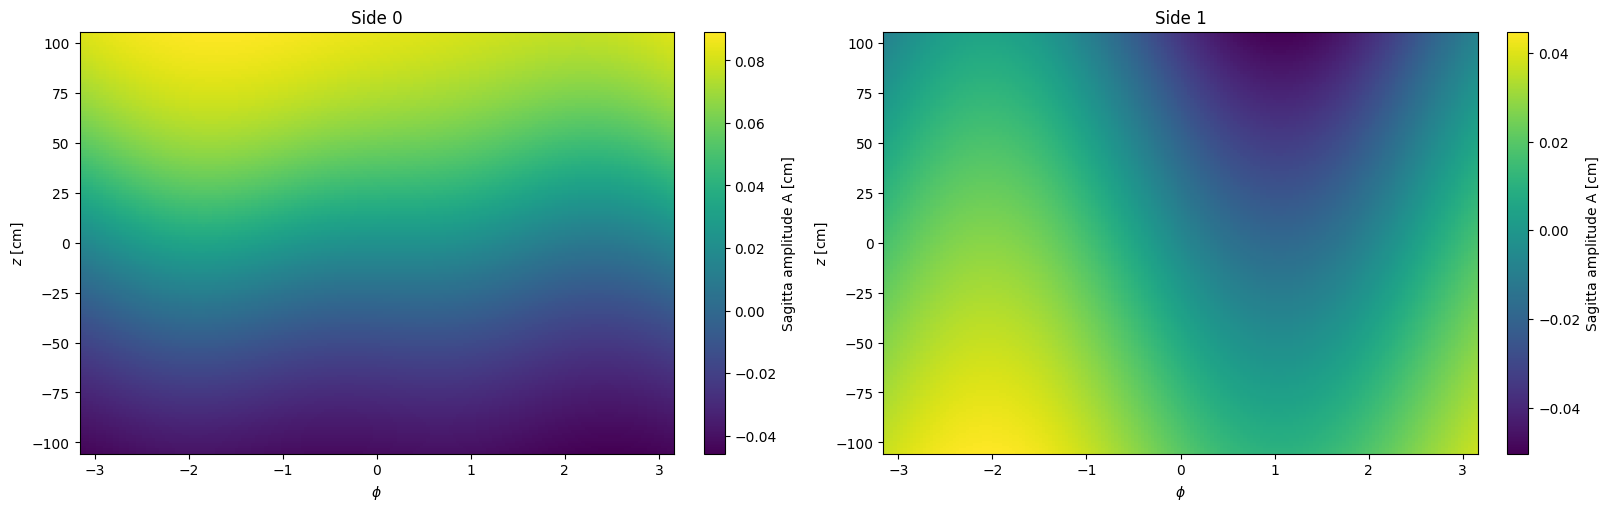

In [21]:
# ============================================================
# Spatial-map QA
# ============================================================

phi_display = np.linspace(
    -math.pi,
    math.pi,
    180,
)

z_display = np.linspace(
    -105.0,
    105.0,
    160,
)

phi_mesh, z_mesh = np.meshgrid(
    phi_display,
    z_display,
    indexing="xy",
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(16, 5),
    constrained_layout=True,
)

for side in [0, 1]:
    statistics = (
        ensemble_amplitude_numpy(
            side,
            phi_mesh,
            z_mesh,
        )
    )

    image = axes[
        side
    ].pcolormesh(
        phi_display,
        z_display,
        statistics["mean"],
        shading="auto",
    )

    axes[side].set_xlabel(
        r"$\phi$"
    )

    axes[side].set_ylabel(
        r"$z$ [cm]"
    )

    axes[side].set_title(
        f"Side {side}"
    )

    figure.colorbar(
        image,
        ax=axes[side],
        label=(
            "Sagitta amplitude "
            "A [cm]"
        ),
    )

plt.show()


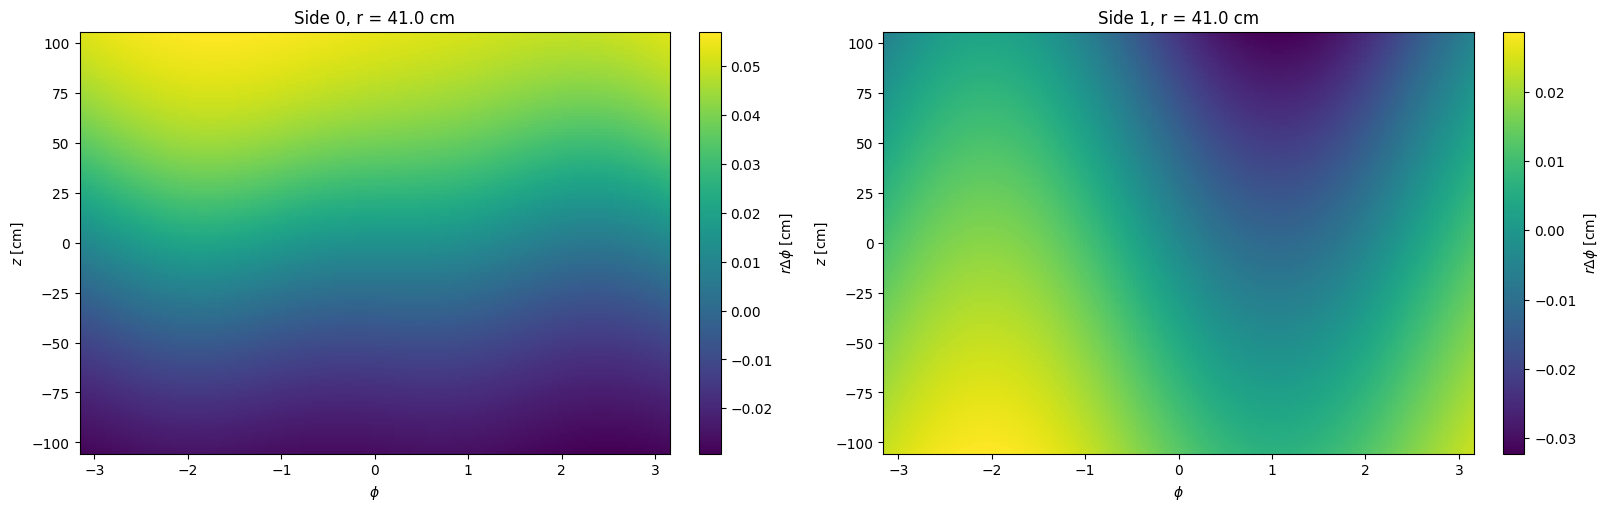

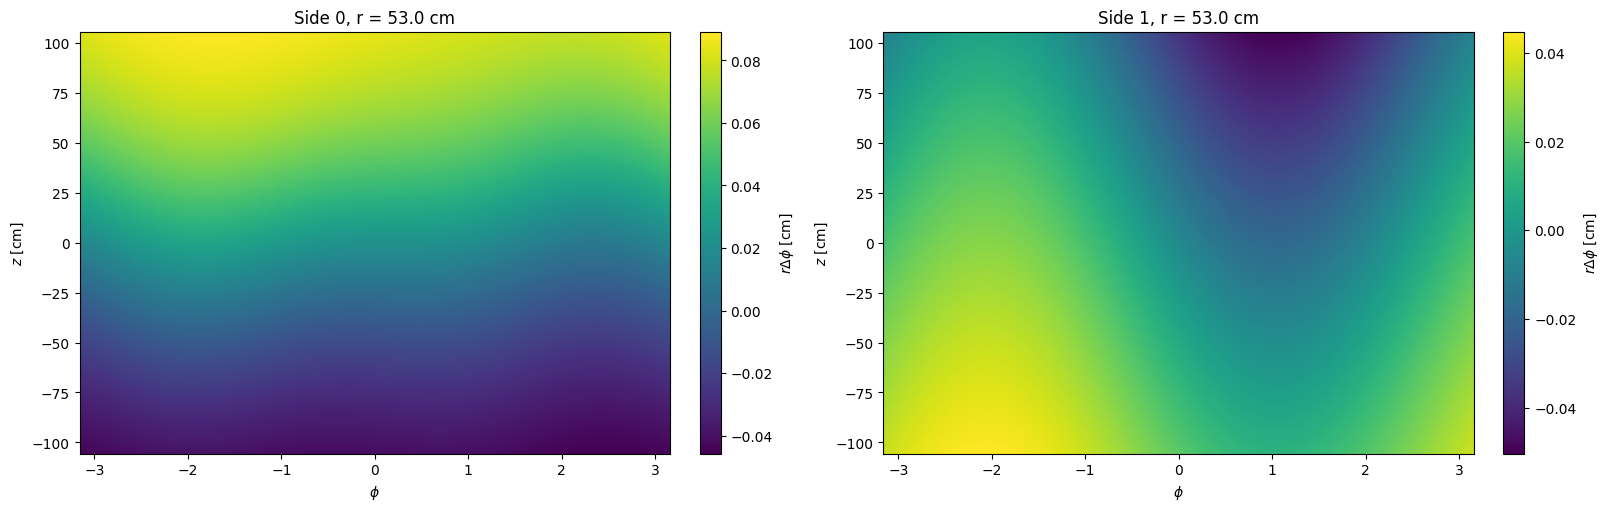

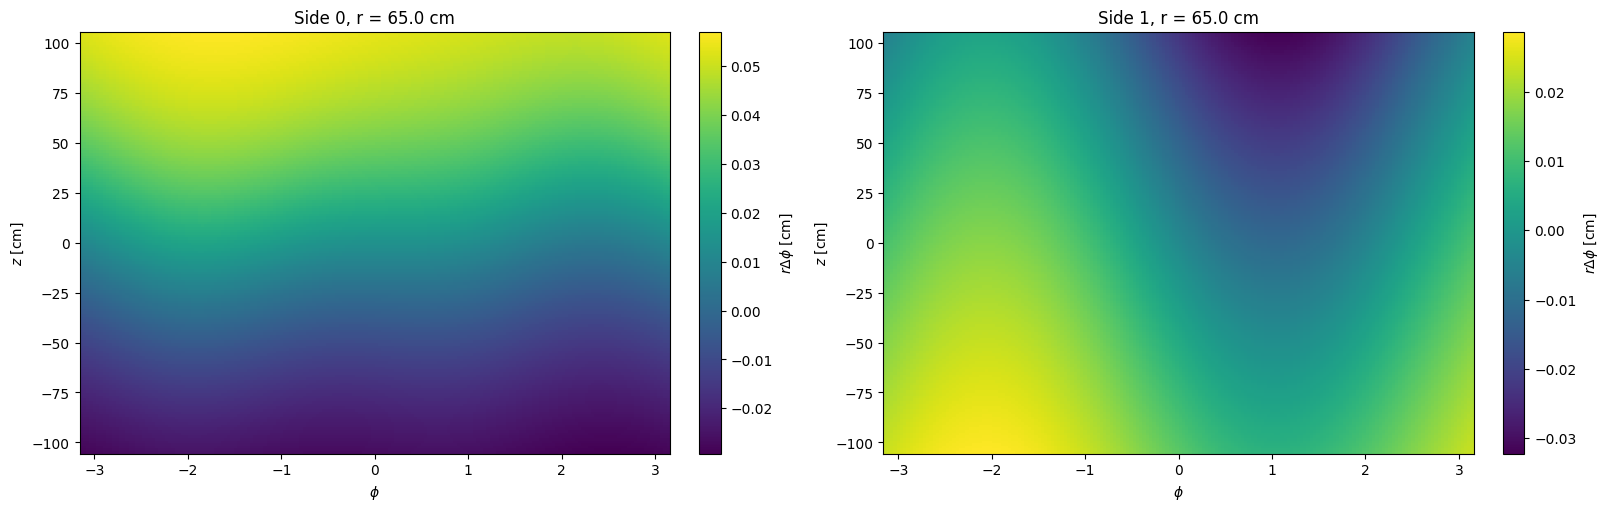

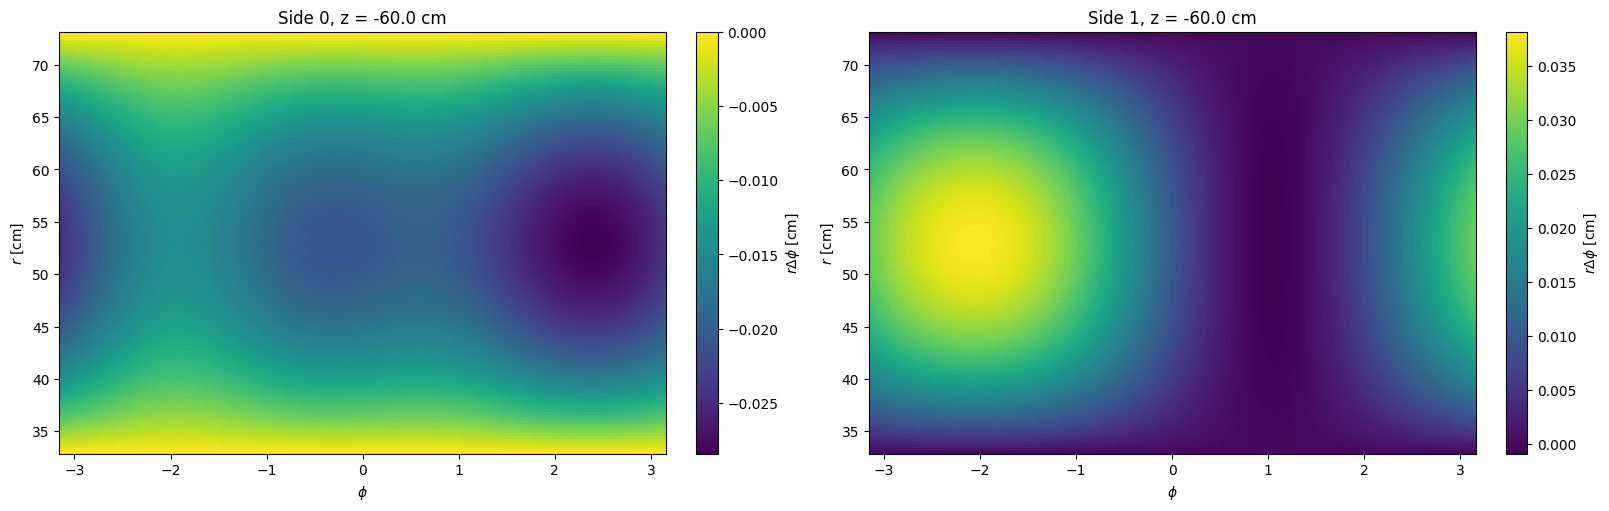

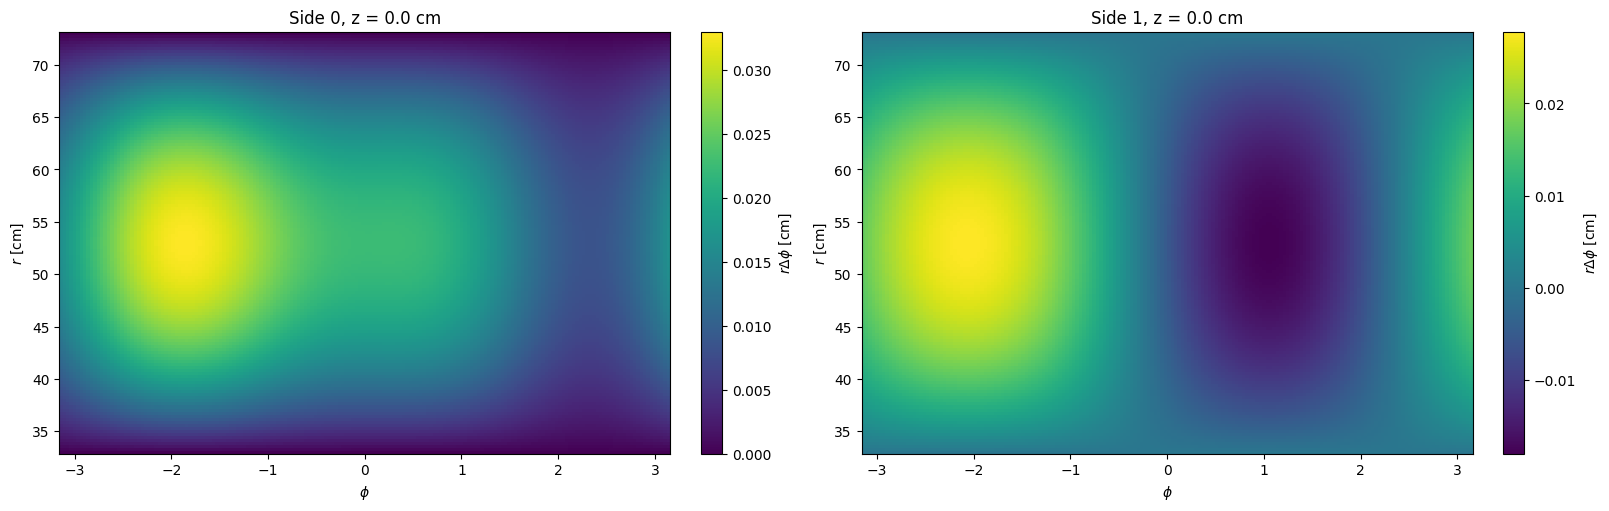

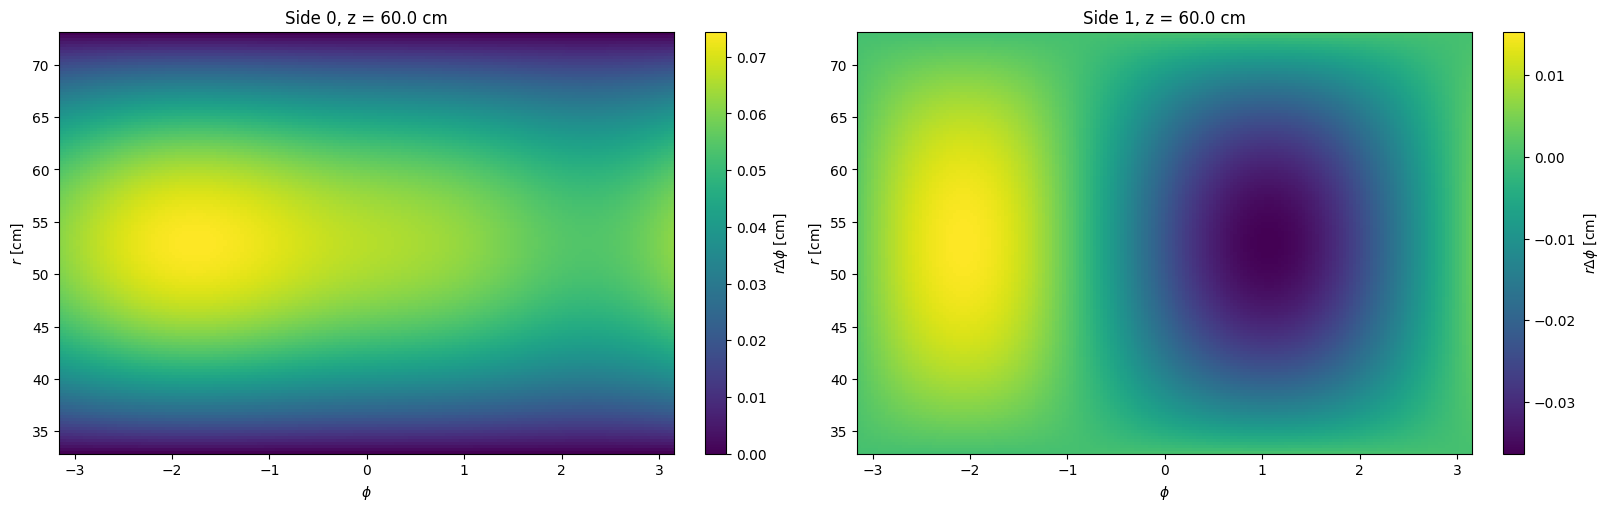

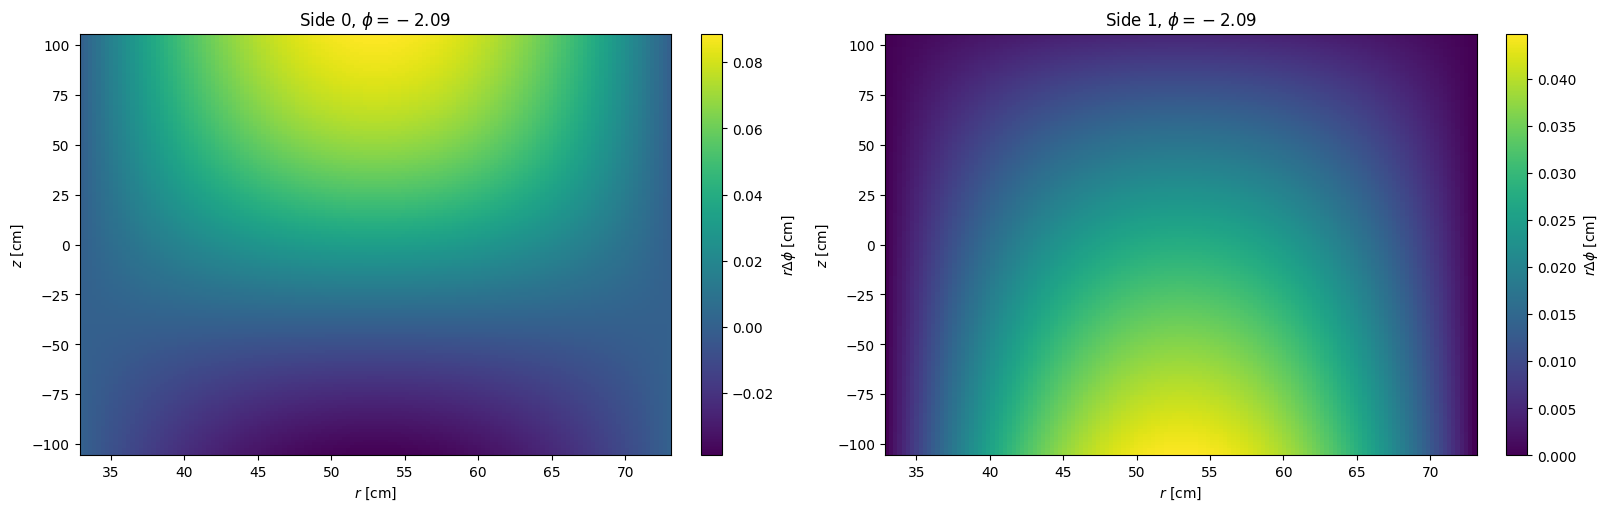

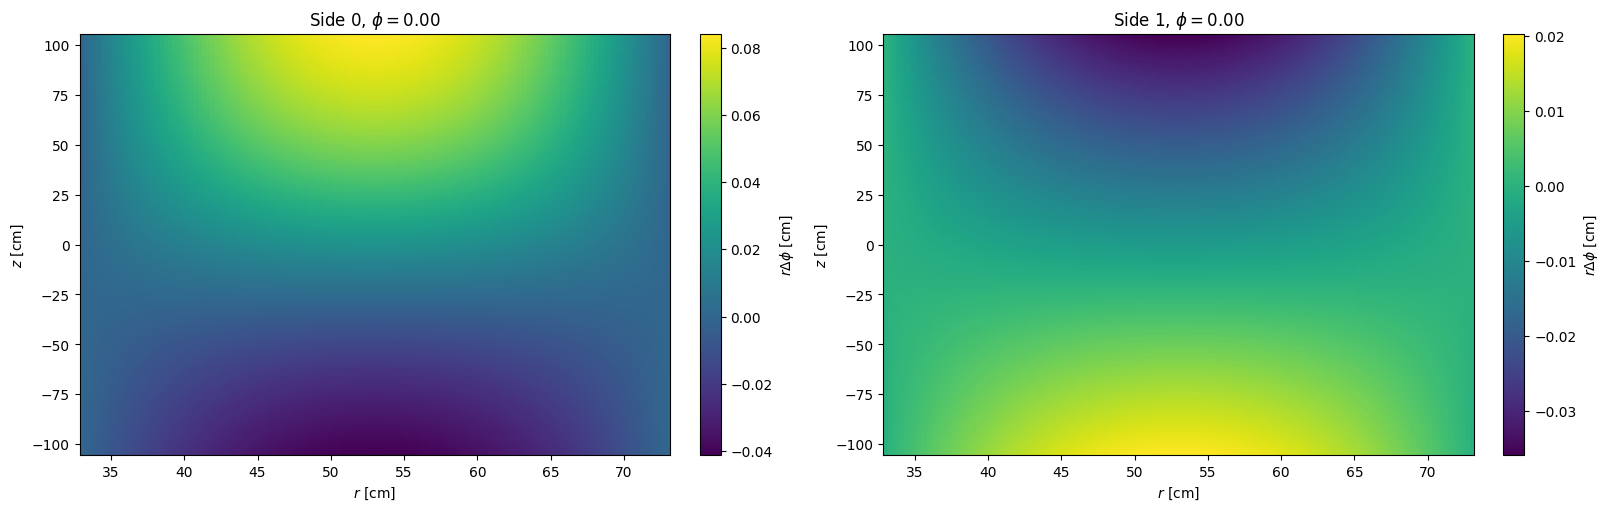

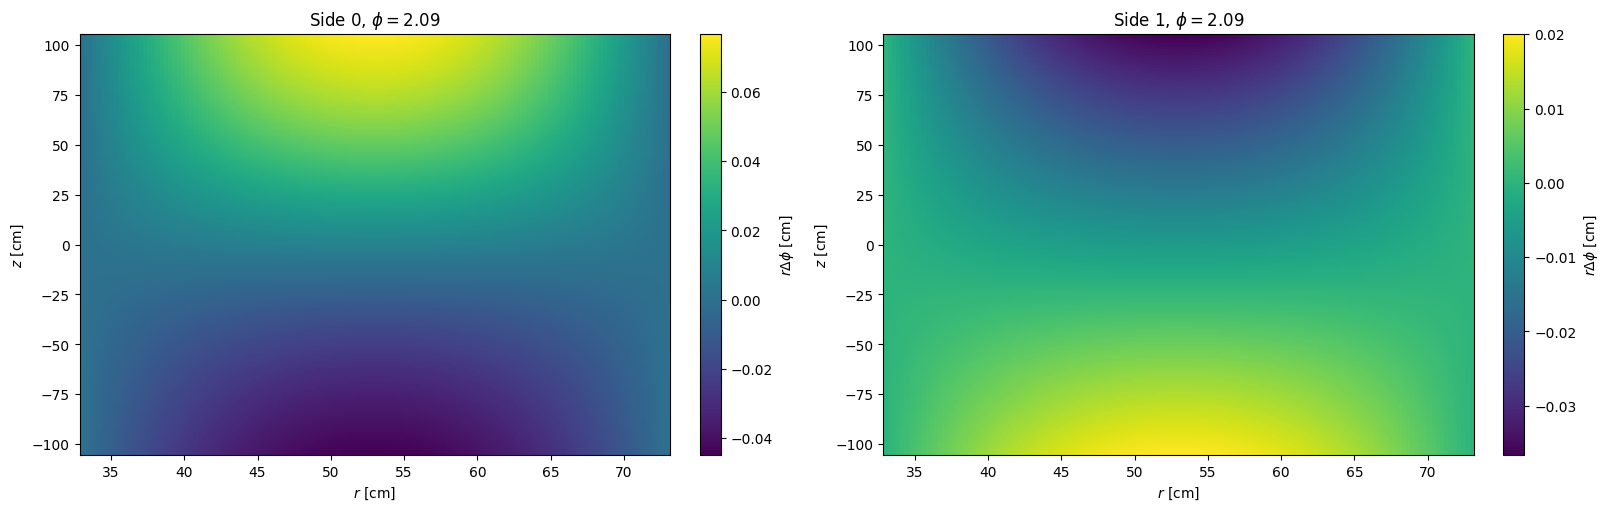

In [26]:
# ============================================================
# Spatial-map QA:
# slices of rDeltaPhi in phi-z, phi-r, and r-z
# ============================================================

phi_display = np.linspace(
    -math.pi,
    math.pi,
    180,
)

z_display = np.linspace(
    -105.0,
    105.0,
    160,
)

r_display = np.linspace(
    sagitta_inner_radius_cm,
    sagitta_outer_radius_cm,
    140,
)


def sagitta_radial_basis(
    radius,
):
    radius = np.asarray(
        radius,
        dtype=np.float64,
    )

    return (
        4.0
        * (
            radius
            - sagitta_inner_radius_cm
        )
        * (
            sagitta_outer_radius_cm
            - radius
        )
        / (
            (
                sagitta_outer_radius_cm
                - sagitta_inner_radius_cm
            ) ** 2
        )
    )


# ============================================================
# 1. phi-z slices at several fixed radii
# ============================================================

fixed_radii_cm = [
    41.0,
    53.0,
    65.0,
]

phi_mesh, z_mesh = np.meshgrid(
    phi_display,
    z_display,
    indexing="xy",
)

for fixed_radius_cm in fixed_radii_cm:

    radial_factor = sagitta_radial_basis(
        fixed_radius_cm
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(16, 5),
        constrained_layout=True,
    )

    for side in [0, 1]:

        statistics = ensemble_amplitude_numpy(
            side,
            phi_mesh,
            z_mesh,
        )

        r_delta_phi = (
            statistics["mean"]
            * radial_factor
        )

        image = axes[side].pcolormesh(
            phi_display,
            z_display,
            r_delta_phi,
            shading="auto",
        )

        axes[side].set_xlabel(
            r"$\phi$"
        )

        axes[side].set_ylabel(
            r"$z$ [cm]"
        )

        axes[side].set_title(
            (
                f"Side {side}, "
                f"r = {fixed_radius_cm:.1f} cm"
            )
        )

        figure.colorbar(
            image,
            ax=axes[side],
            label=(
                r"$r\Delta\phi$ [cm]"
            ),
        )

    plt.show()


# ============================================================
# 2. phi-r slices at several fixed z values
# ============================================================

fixed_z_values_cm = [
    -60.0,
    0.0,
    60.0,
]

phi_mesh, r_mesh = np.meshgrid(
    phi_display,
    r_display,
    indexing="xy",
)

radial_factor_mesh = (
    sagitta_radial_basis(
        r_mesh
    )
)

for fixed_z_cm in fixed_z_values_cm:

    z_mesh_fixed = np.full_like(
        phi_mesh,
        fixed_z_cm,
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(16, 5),
        constrained_layout=True,
    )

    for side in [0, 1]:

        statistics = ensemble_amplitude_numpy(
            side,
            phi_mesh,
            z_mesh_fixed,
        )

        r_delta_phi = (
            statistics["mean"]
            * radial_factor_mesh
        )

        image = axes[side].pcolormesh(
            phi_display,
            r_display,
            r_delta_phi,
            shading="auto",
        )

        axes[side].set_xlabel(
            r"$\phi$"
        )

        axes[side].set_ylabel(
            r"$r$ [cm]"
        )

        axes[side].set_title(
            (
                f"Side {side}, "
                f"z = {fixed_z_cm:.1f} cm"
            )
        )

        figure.colorbar(
            image,
            ax=axes[side],
            label=(
                r"$r\Delta\phi$ [cm]"
            ),
        )

    plt.show()


# ============================================================
# 3. r-z slices at several fixed phi values
# ============================================================

fixed_phi_values = [
    -2.0 * math.pi / 3.0,
    0.0,
    2.0 * math.pi / 3.0,
]

r_mesh, z_mesh = np.meshgrid(
    r_display,
    z_display,
    indexing="xy",
)

radial_factor_mesh = (
    sagitta_radial_basis(
        r_mesh
    )
)

for fixed_phi in fixed_phi_values:

    phi_mesh_fixed = np.full_like(
        z_mesh,
        fixed_phi,
    )

    figure, axes = plt.subplots(
        1,
        2,
        figsize=(16, 5),
        constrained_layout=True,
    )

    for side in [0, 1]:

        statistics = ensemble_amplitude_numpy(
            side,
            phi_mesh_fixed,
            z_mesh,
        )

        r_delta_phi = (
            statistics["mean"]
            * radial_factor_mesh
        )

        image = axes[side].pcolormesh(
            r_display,
            z_display,
            r_delta_phi,
            shading="auto",
        )

        axes[side].set_xlabel(
            r"$r$ [cm]"
        )

        axes[side].set_ylabel(
            r"$z$ [cm]"
        )

        axes[side].set_title(
            (
                f"Side {side}, "
                rf"$\phi={fixed_phi:.2f}$"
            )
        )

        figure.colorbar(
            image,
            ax=axes[side],
            label=(
                r"$r\Delta\phi$ [cm]"
            ),
        )

    plt.show()

side 0 before: {'mean': 0.4998635877495589, 'width': 0.012815069874631553, 'entries': 6621}
side 0 after: {'mean': 0.49979290095775875, 'width': 0.012745097339057588, 'entries': 6634}
side 1 before: {'mean': 0.49956464651018084, 'width': 0.012805087307719502, 'entries': 5752}
side 1 after: {'mean': 0.4995102042238196, 'width': 0.012615326383166123, 'entries': 5770}


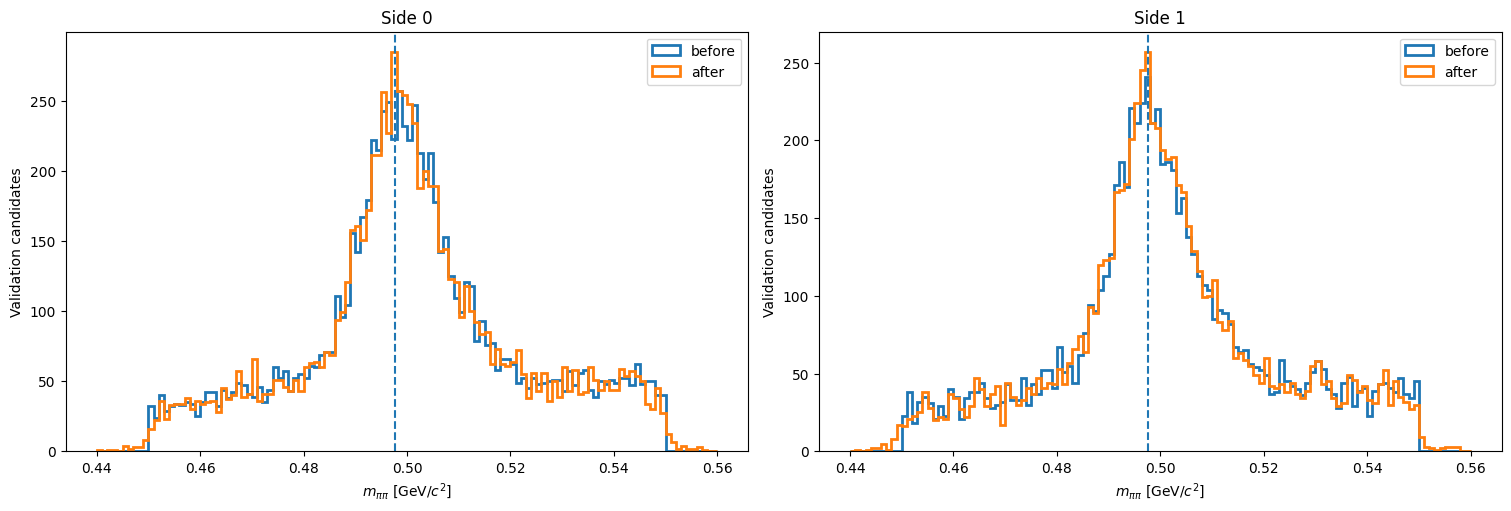

Wrote: output/k0s_sagitta_spatial_dnn_cut03/k0s_mass_validation_by_pt_side0.pdf


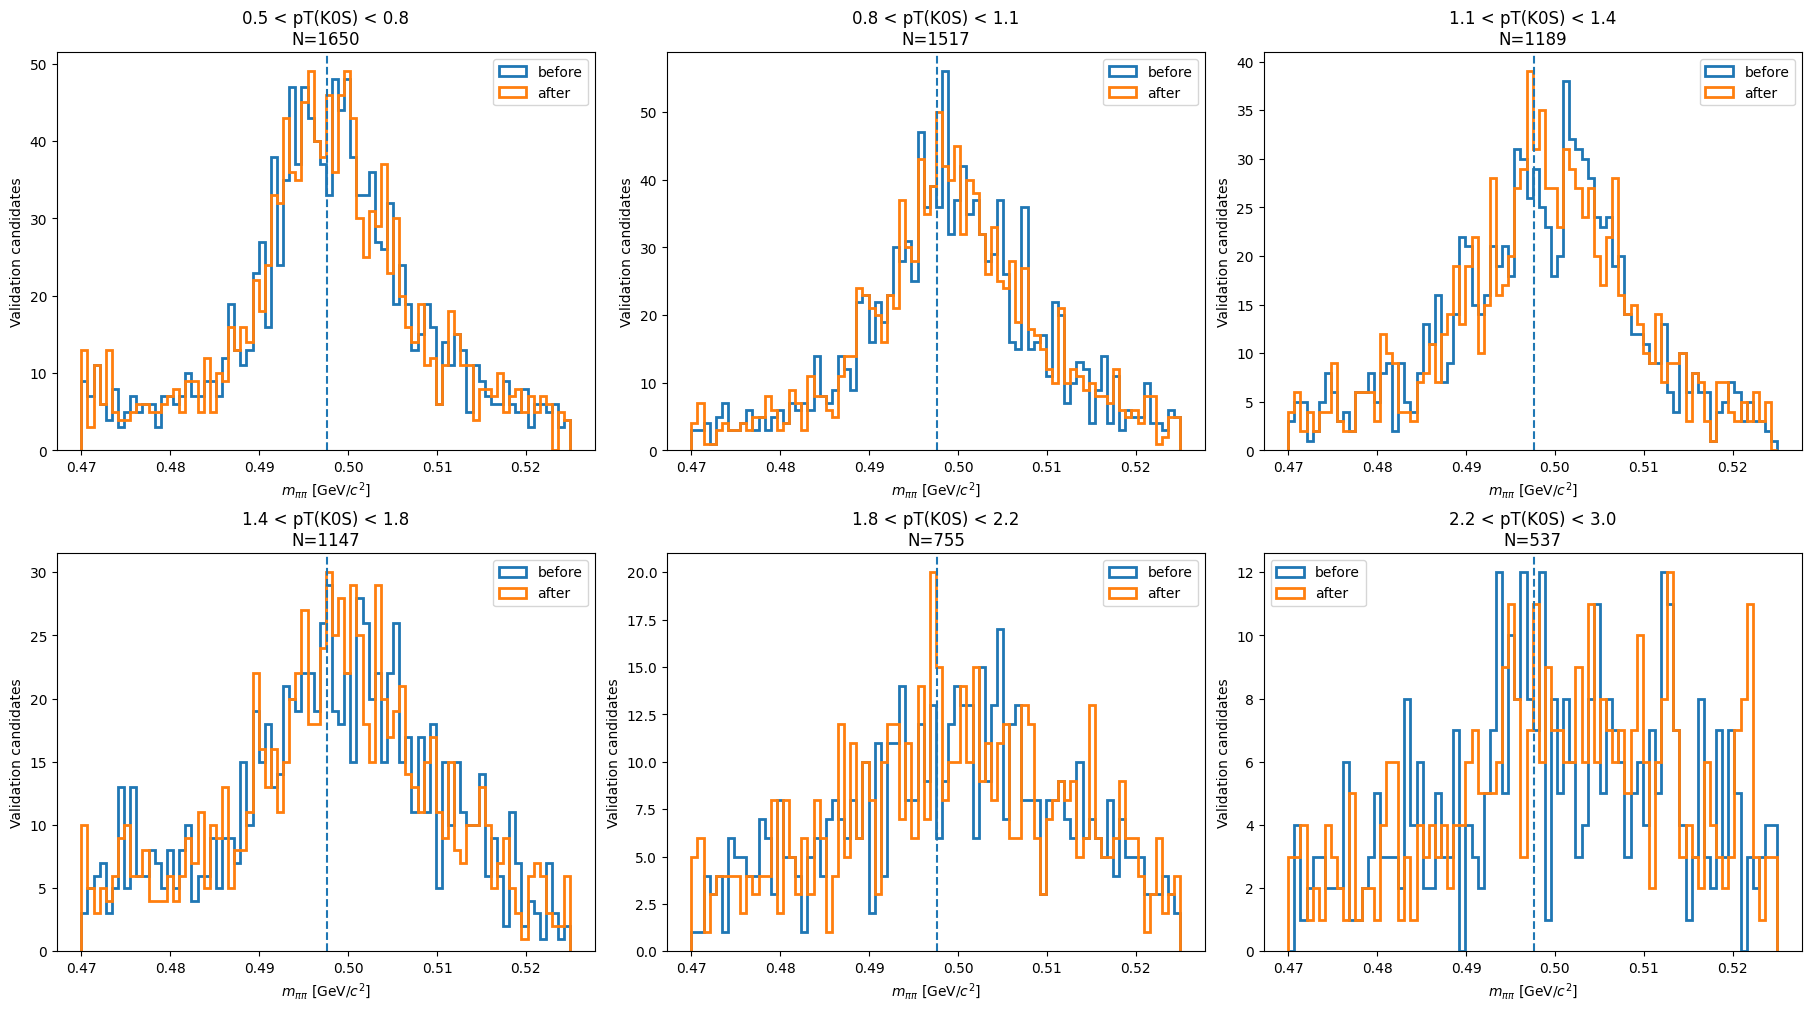

Wrote: output/k0s_sagitta_spatial_dnn_cut03/k0s_mass_validation_by_pt_side1.pdf


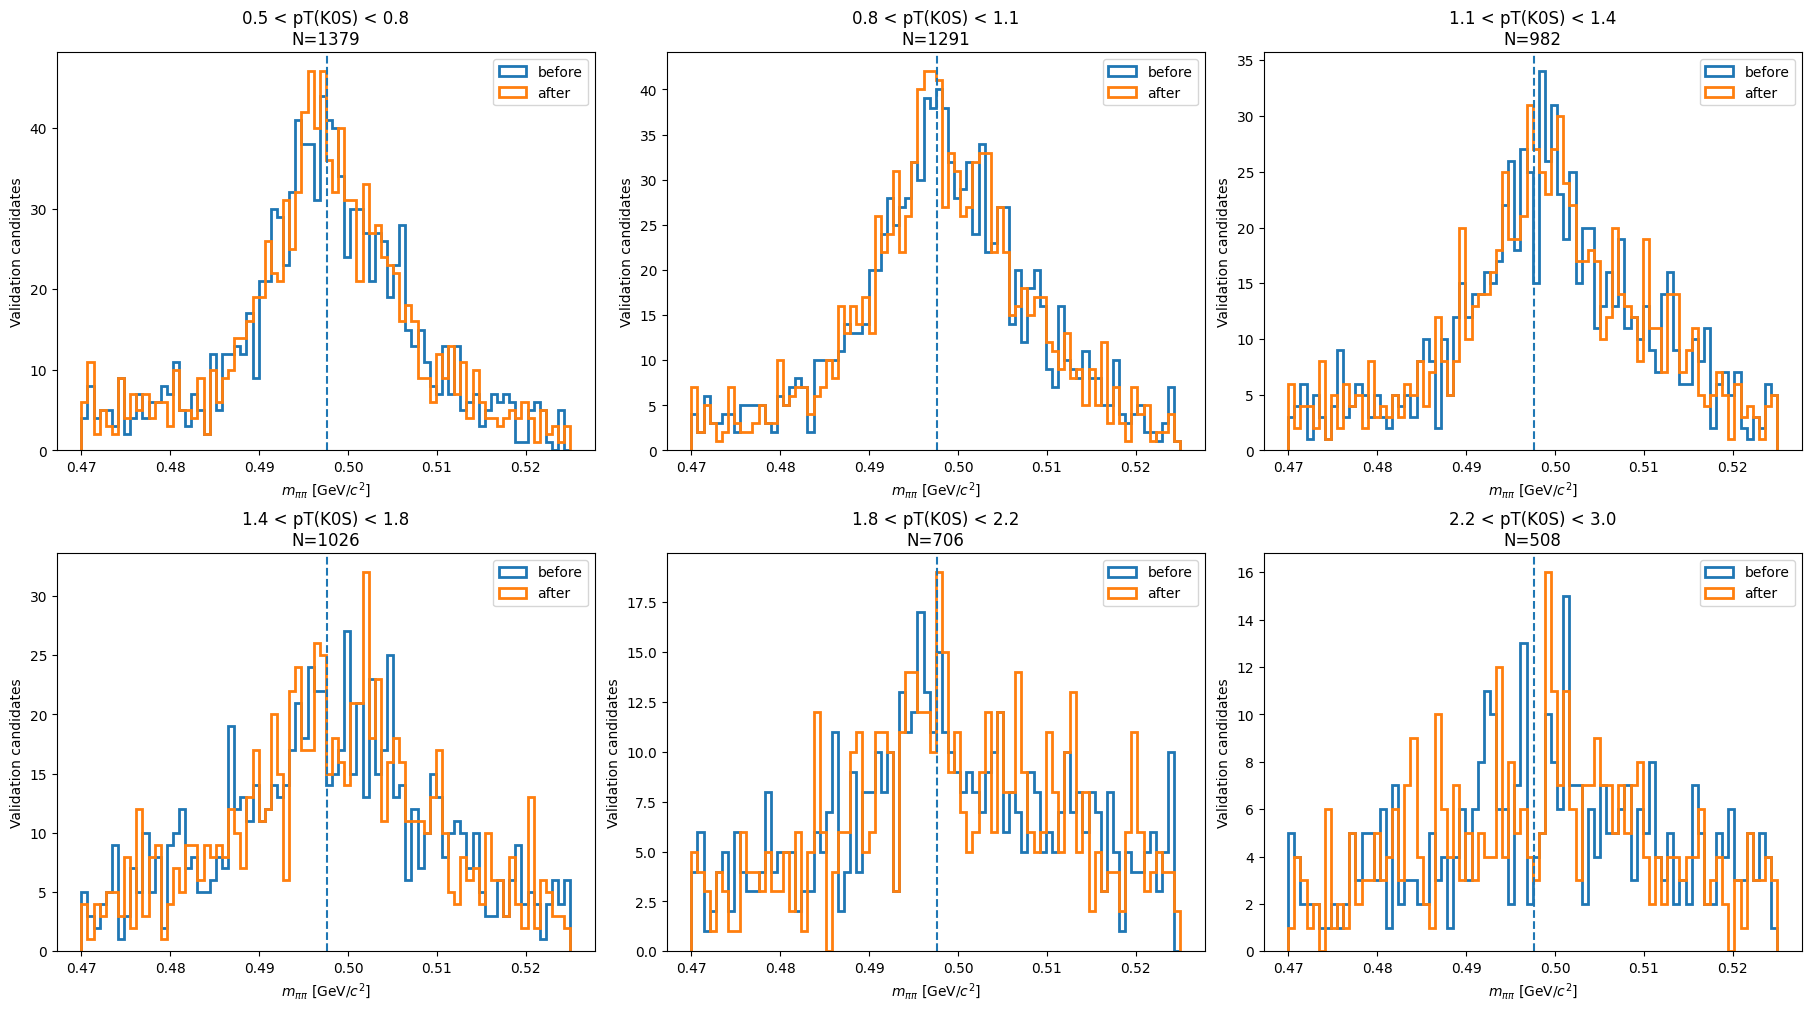

,side,pt_minimum,pt_maximum,pt_center,entries,mean_before,mean_after,width_before,width_after,width_ratio
0,0,0.5,0.8,0.65,1650,0.498471,0.498288,0.011565,0.011568,1.000290
1,0,0.8,1.1,0.95,1517,0.499902,0.499912,0.011115,0.011088,0.997600
2,0,1.1,1.4,1.25,1189,0.498947,0.498900,0.011579,0.011350,0.980231
3,0,1.4,1.8,1.60,1147,0.498731,0.498547,0.012804,0.012473,0.974094
4,0,1.8,2.2,2.00,755,0.499944,0.499931,0.013864,0.014069,1.014733
5,0,2.2,3.0,2.60,537,0.502249,0.502287,0.014897,0.014741,0.989558
6,1,0.5,0.8,0.65,1379,0.497998,0.497998,0.011195,0.011225,1.002661
7,1,0.8,1.1,0.95,1291,0.498864,0.498936,0.010886,0.010853,0.996892
8,1,1.1,1.4,1.25,982,0.499864,0.499610,0.012021,0.011821,0.983302
9,1,1.4,1.8,1.60,1026,0.498670,0.498851,0.013122,0.012756,0.972119


In [22]:
# ============================================================
# Inclusive and pT-binned unweighted K0S validation
# ============================================================

def corrected_mass_for_frame(
    frame,
    side,
):
    corrected1 = (
        correct_tracks_with_ensemble_numpy(
            side=side,
            charge=frame[
                "charge1"
            ].to_numpy(),
            pt=frame[
                "pt1"
            ].to_numpy(),
            phi_vertex=frame[
                "phi1"
            ].to_numpy(),
            eta=frame[
                "eta1"
            ].to_numpy(),
            vertex_x_cm=frame[
                "pca_x"
            ].to_numpy(),
            vertex_y_cm=frame[
                "pca_y"
            ].to_numpy(),
            vertex_z_cm=frame[
                "pca_z"
            ].to_numpy(),
        )
    )

    corrected2 = (
        correct_tracks_with_ensemble_numpy(
            side=side,
            charge=frame[
                "charge2"
            ].to_numpy(),
            pt=frame[
                "pt2"
            ].to_numpy(),
            phi_vertex=frame[
                "phi2"
            ].to_numpy(),
            eta=frame[
                "eta2"
            ].to_numpy(),
            vertex_x_cm=frame[
                "pca_x"
            ].to_numpy(),
            vertex_y_cm=frame[
                "pca_y"
            ].to_numpy(),
            vertex_z_cm=frame[
                "pca_z"
            ].to_numpy(),
        )
    )

    momentum1 = np.column_stack([
        corrected1["px"],
        corrected1["py"],
        corrected1["pz"],
    ])

    momentum2 = np.column_stack([
        corrected2["px"],
        corrected2["py"],
        corrected2["pz"],
    ])

    energy1 = np.sqrt(
        np.sum(
            momentum1 ** 2,
            axis=1,
        )
        + pion_mass ** 2
    )

    energy2 = np.sqrt(
        np.sum(
            momentum2 ** 2,
            axis=1,
        )
        + pion_mass ** 2
    )

    total = (
        momentum1 + momentum2
    )

    mass_squared = (
        (energy1 + energy2) ** 2
        - np.sum(
            total ** 2,
            axis=1,
        )
    )

    return np.sqrt(
        np.clip(
            mass_squared,
            0.0,
            None,
        )
    )


validation_rows = []

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    constrained_layout=True,
)

for side in [0, 1]:
    frame = selected.loc[
        (
            selected["side"]
            == side
        )
        & (
            selected[
                "entry_parity"
            ] == validation_parity
        )
    ].copy()

    frame["mass_after"] = (
        corrected_mass_for_frame(
            frame,
            side,
        )
    )

    before = frame[
        "mass_before"
    ].to_numpy()

    after = frame[
        "mass_after"
    ].to_numpy()

    print(
        f"side {side} before:",
        peak_metrics(before),
    )

    print(
        f"side {side} after:",
        peak_metrics(after),
    )

    axes[side].hist(
        before,
        bins=120,
        range=(
            validation_mass_minimum,
            validation_mass_maximum,
        ),
        histtype="step",
        linewidth=2,
        label="before",
    )

    axes[side].hist(
        after,
        bins=120,
        range=(
            validation_mass_minimum,
            validation_mass_maximum,
        ),
        histtype="step",
        linewidth=2,
        label="after",
    )

    axes[side].axvline(
        pdg_kshort_mass,
        linestyle="--",
    )

    axes[side].set_xlabel(
        r"$m_{\pi\pi}$ "
        r"[GeV/$c^2$]"
    )

    axes[side].set_ylabel(
        "Validation candidates"
    )

    axes[side].set_title(
        f"Side {side}"
    )

    axes[side].legend()

plt.show()


for side in [0, 1]:
    frame = selected.loc[
        (
            selected["side"]
            == side
        )
        & (
            selected[
                "entry_parity"
            ] == validation_parity
        )
    ].copy()

    frame["mass_after"] = (
        corrected_mass_for_frame(
            frame,
            side,
        )
    )

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(18, 10),
        constrained_layout=True,
    )

    for (
        bin_index,
        axis,
    ) in enumerate(
        axes.flat
    ):
        pt_minimum = (
            kshort_pt_bin_edges[
                bin_index
            ]
        )

        pt_maximum = (
            kshort_pt_bin_edges[
                bin_index + 1
            ]
        )

        subset = frame.loc[
            (
                frame["kshort_pt"]
                >= pt_minimum
            )
            & (
                frame["kshort_pt"]
                < pt_maximum
            )
        ]

        before = subset[
            "mass_before"
        ].to_numpy()

        after = subset[
            "mass_after"
        ].to_numpy()

        before_metrics = (
            peak_metrics(before)
        )

        after_metrics = (
            peak_metrics(after)
        )

        width_ratio = (
            after_metrics["width"]
            / before_metrics["width"]
            if (
                np.isfinite(
                    after_metrics["width"]
                )
                and np.isfinite(
                    before_metrics["width"]
                )
                and before_metrics[
                    "width"
                ] > 0
            )
            else np.nan
        )

        validation_rows.append({
            "side": side,
            "pt_minimum": (
                pt_minimum
            ),
            "pt_maximum": (
                pt_maximum
            ),
            "pt_center": 0.5 * (
                pt_minimum
                + pt_maximum
            ),
            "entries": int(
                len(subset)
            ),
            "mean_before": (
                before_metrics["mean"]
            ),
            "mean_after": (
                after_metrics["mean"]
            ),
            "width_before": (
                before_metrics["width"]
            ),
            "width_after": (
                after_metrics["width"]
            ),
            "width_ratio": (
                width_ratio
            ),
        })

        axis.hist(
            before,
            bins=80,
            range=(
                0.47,
                0.525,
            ),
            histtype="step",
            linewidth=2,
            label="before",
        )

        axis.hist(
            after,
            bins=80,
            range=(
                0.47,
                0.525,
            ),
            histtype="step",
            linewidth=2,
            label="after",
        )

        axis.axvline(
            pdg_kshort_mass,
            linestyle="--",
        )

        axis.set_title(
            (
                f"{pt_minimum:.1f}"
                f" < pT(K0S) < "
                f"{pt_maximum:.1f}\n"
                f"N={len(subset)}"
            )
        )

        axis.set_xlabel(
            r"$m_{\pi\pi}$ "
            r"[GeV/$c^2$]"
        )

        axis.set_ylabel(
            "Validation candidates"
        )

        axis.legend()

    output_plot = (
        work_dir
        / (
            "k0s_mass_validation_"
            f"by_pt_side{side}.pdf"
        )
    )

    figure.savefig(
        output_plot
    )

    print(
        "Wrote:",
        output_plot,
    )

    plt.show()


validation_summary = pd.DataFrame(
    validation_rows
)

validation_summary.to_csv(
    work_dir
    / "k0s_mass_validation_by_pt.csv",
    index=False,
)

display(
    validation_summary
)


## Export spatial maps

The physical outputs are:

```text
side0/h2_sagitta_amplitude
side1/h2_sagitta_amplitude
```

with axes \((\phi,z)\), and

```text
side0/h3_rdelta_phi
side1/h3_rdelta_phi
```

with axes \((r,\phi,z)\).

The exported correction has units of centimeters:

\[
r\Delta\phi\ [\mathrm{cm}].
\]


In [23]:
# ============================================================
# Export A(phi,z) and rDeltaPhi(r,phi,z)
# ============================================================

spatial_map_root_file = (
    work_dir
    / "k0s_sagitta_spatial_map.root"
)

spatial_map_csv_file = (
    work_dir
    / "k0s_sagitta_spatial_map_grid.csv"
)

map_phi_edges = np.linspace(
    -math.pi,
    math.pi,
    49,
)

map_z_edges = np.linspace(
    -105.0,
    105.0,
    43,
)

map_r_edges = np.array([
    33.0,
    37.0,
    41.0,
    45.0,
    49.0,
    53.0,
    57.0,
    61.0,
    65.0,
    69.0,
    73.0,
], dtype=np.float64)

map_phi_centers = 0.5 * (
    map_phi_edges[:-1]
    + map_phi_edges[1:]
)

map_z_centers = 0.5 * (
    map_z_edges[:-1]
    + map_z_edges[1:]
)

map_r_centers = 0.5 * (
    map_r_edges[:-1]
    + map_r_edges[1:]
)

spatial_rows = []

for side in [0, 1]:
    phi_grid, z_grid = np.meshgrid(
        map_phi_centers,
        map_z_centers,
        indexing="ij",
    )

    statistics = (
        ensemble_amplitude_numpy(
            side,
            phi_grid,
            z_grid,
        )
    )

    for (
        phi_value,
        z_value,
        amplitude_value,
        amplitude_std,
    ) in zip(
        phi_grid.ravel(),
        z_grid.ravel(),
        statistics["mean"].ravel(),
        statistics["std"].ravel(),
    ):
        for radius_value in (
            map_r_centers
        ):
            radial_basis = (
                4.0
                * (
                    radius_value
                    - sagitta_inner_radius_cm
                )
                * (
                    sagitta_outer_radius_cm
                    - radius_value
                )
                / (
                    (
                        sagitta_outer_radius_cm
                        - sagitta_inner_radius_cm
                    ) ** 2
                )
            )

            spatial_rows.append({
                "side": side,
                "radius_cm": (
                    radius_value
                ),
                "phi": phi_value,
                "z_cm": z_value,
                "sagitta_amplitude_cm": (
                    amplitude_value
                ),
                "sagitta_amplitude_std_cm": (
                    amplitude_std
                ),
                "r_delta_phi_cm": (
                    amplitude_value
                    * radial_basis
                ),
                "r_delta_phi_std_cm": (
                    amplitude_std
                    * abs(radial_basis)
                ),
            })

spatial_grid = pd.DataFrame(
    spatial_rows
)

spatial_grid.to_csv(
    spatial_map_csv_file,
    index=False,
)

print(
    "Wrote:",
    spatial_map_csv_file,
)

if root is None:
    print(
        "PyROOT unavailable; "
        "ROOT spatial map not written."
    )
else:
    output = root.TFile.Open(
        str(
            spatial_map_root_file
        ),
        "RECREATE",
    )

    if not output or output.IsZombie():
        raise OSError(
            "Could not create "
            f"{spatial_map_root_file}"
        )

    root.TNamed(
        "method",
        (
            "K0S-constrained six-radius "
            "sagitta spatial DNN; "
            f"B={magnetic_field_tesla} T; "
            f"pseudo radii="
            f"{pseudo_radii_cm.tolist()}"
        ),
    ).Write()

    for side in [0, 1]:
        side_directory = output.mkdir(
            f"side{side}"
        )

        side_directory.cd()

        amplitude_histogram = root.TH2D(
            "h2_sagitta_amplitude",
            (
                "Sagitta amplitude;"
                "#phi;"
                "z [cm]"
            ),
            len(map_phi_edges) - 1,
            array(
                "d",
                map_phi_edges,
            ),
            len(map_z_edges) - 1,
            array(
                "d",
                map_z_edges,
            ),
        )

        amplitude_std_histogram = (
            root.TH2D(
                "h2_sagitta_amplitude_ensemble_std",
                (
                    "Sagitta amplitude ensemble spread;"
                    "#phi;"
                    "z [cm]"
                ),
                len(map_phi_edges) - 1,
                array(
                    "d",
                    map_phi_edges,
                ),
                len(map_z_edges) - 1,
                array(
                    "d",
                    map_z_edges,
                ),
            )
        )

        rdelta_histogram = root.TH3D(
            "h3_rdelta_phi",
            (
                "Azimuthal spatial correction;"
                "r [cm];"
                "#phi;"
                "z [cm]"
            ),
            len(map_r_edges) - 1,
            array(
                "d",
                map_r_edges,
            ),
            len(map_phi_edges) - 1,
            array(
                "d",
                map_phi_edges,
            ),
            len(map_z_edges) - 1,
            array(
                "d",
                map_z_edges,
            ),
        )

        rdelta_std_histogram = (
            root.TH3D(
                "h3_rdelta_phi_ensemble_std",
                (
                    "Azimuthal correction ensemble spread;"
                    "r [cm];"
                    "#phi;"
                    "z [cm]"
                ),
                len(map_r_edges) - 1,
                array(
                    "d",
                    map_r_edges,
                ),
                len(map_phi_edges) - 1,
                array(
                    "d",
                    map_phi_edges,
                ),
                len(map_z_edges) - 1,
                array(
                    "d",
                    map_z_edges,
                ),
            )
        )

        subset = spatial_grid.loc[
            spatial_grid["side"]
            == side
        ]

        amplitude_subset = (
            subset.drop_duplicates(
                [
                    "phi",
                    "z_cm",
                ]
            )
        )

        for row in (
            amplitude_subset
            .itertuples(
                index=False
            )
        ):
            global_bin = (
                amplitude_histogram.FindBin(
                    row.phi,
                    row.z_cm,
                )
            )

            amplitude_histogram.SetBinContent(
                global_bin,
                row.sagitta_amplitude_cm,
            )

            amplitude_std_histogram.SetBinContent(
                global_bin,
                row.sagitta_amplitude_std_cm,
            )

        for row in subset.itertuples(
            index=False
        ):
            global_bin = (
                rdelta_histogram.FindBin(
                    row.radius_cm,
                    row.phi,
                    row.z_cm,
                )
            )

            rdelta_histogram.SetBinContent(
                global_bin,
                row.r_delta_phi_cm,
            )

            rdelta_std_histogram.SetBinContent(
                global_bin,
                row.r_delta_phi_std_cm,
            )

        amplitude_histogram.Write()
        amplitude_std_histogram.Write()
        rdelta_histogram.Write()
        rdelta_std_histogram.Write()

    output.Close()

    print(
        "Wrote:",
        spatial_map_root_file,
    )


Wrote: output/k0s_sagitta_spatial_dnn_cut03/k0s_sagitta_spatial_map_grid.csv
Wrote: output/k0s_sagitta_spatial_dnn_cut03/k0s_sagitta_spatial_map.root


## Export standard prompt-track maps

For compatibility with existing validation code, the notebook evaluates the spatial forward model for prompt tracks originating from the fixed beam position and writes:

```text
side0/qminus/h3_momentum_scale
side0/qplus/h3_momentum_scale
side1/qminus/h3_momentum_scale
side1/qplus/h3_momentum_scale
```

with axes:

- \(p_T\);
- momentum \(\phi\) at the production vertex;
- \(\eta\).

It also writes the derived tangent-angle shift.


In [24]:
# ============================================================
# Export derived prompt-track momentum-scale and phi-shift maps
# ============================================================

prompt_map_root_file = (
    work_dir
    / "k0s_sagitta_prompt_track_map.root"
)

prompt_map_csv_file = (
    work_dir
    / "k0s_sagitta_prompt_track_map_grid.csv"
)

prompt_pt_edges = np.array([
    0.20,
    0.30,
    0.40,
    0.55,
    0.70,
    0.90,
    1.20,
    1.50,
    2.00,
    3.00,
    5.00,
], dtype=np.float64)

prompt_phi_edges = np.linspace(
    -math.pi,
    math.pi,
    49,
)

prompt_eta_edges = np.linspace(
    -1.10,
    1.10,
    23,
)

prompt_pt_centers = 0.5 * (
    prompt_pt_edges[:-1]
    + prompt_pt_edges[1:]
)

prompt_phi_centers = 0.5 * (
    prompt_phi_edges[:-1]
    + prompt_phi_edges[1:]
)

prompt_eta_centers = 0.5 * (
    prompt_eta_edges[:-1]
    + prompt_eta_edges[1:]
)

prompt_rows = []

for side in [0, 1]:
    for charge in [-1, 1]:
        (
            pt_grid,
            phi_grid,
            eta_grid,
        ) = np.meshgrid(
            prompt_pt_centers,
            prompt_phi_centers,
            prompt_eta_centers,
            indexing="ij",
        )

        result = (
            correct_tracks_with_ensemble_numpy(
                side=side,
                charge=np.full(
                    pt_grid.size,
                    charge,
                ),
                pt=pt_grid.ravel(),
                phi_vertex=(
                    phi_grid.ravel()
                ),
                eta=eta_grid.ravel(),
                vertex_x_cm=np.full(
                    pt_grid.size,
                    beam_x_cm,
                ),
                vertex_y_cm=np.full(
                    pt_grid.size,
                    beam_y_cm,
                ),
                vertex_z_cm=np.full(
                    pt_grid.size,
                    beam_z_cm,
                ),
            )
        )

        for (
            pt_value,
            phi_value,
            eta_value,
            scale_value,
            phi_shift_value,
            valid_value,
        ) in zip(
            pt_grid.ravel(),
            phi_grid.ravel(),
            eta_grid.ravel(),
            np.asarray(
                result[
                    "momentum_scale"
                ]
            ).ravel(),
            np.asarray(
                result[
                    "phi_shift"
                ]
            ).ravel(),
            np.asarray(
                result["valid"]
            ).ravel(),
        ):
            prompt_rows.append({
                "side": side,
                "charge": charge,
                "pt": pt_value,
                "phi_vertex": (
                    phi_value
                ),
                "eta": eta_value,
                "momentum_scale": (
                    scale_value
                ),
                "phi_shift": (
                    phi_shift_value
                ),
                "valid": int(
                    valid_value
                ),
            })

prompt_grid = pd.DataFrame(
    prompt_rows
)

prompt_grid.to_csv(
    prompt_map_csv_file,
    index=False,
)

print(
    "Wrote:",
    prompt_map_csv_file,
)

if root is None:
    print(
        "PyROOT unavailable; "
        "prompt ROOT map not written."
    )
else:
    output = root.TFile.Open(
        str(
            prompt_map_root_file
        ),
        "RECREATE",
    )

    if not output or output.IsZombie():
        raise OSError(
            "Could not create "
            f"{prompt_map_root_file}"
        )

    root.TNamed(
        "axis_definition",
        (
            "X=pT [GeV/c]; "
            "Y=momentum phi at production vertex; "
            "Z=eta"
        ),
    ).Write()

    root.TNamed(
        "origin",
        (
            f"beam origin=("
            f"{beam_x_cm},"
            f"{beam_y_cm},"
            f"{beam_z_cm}) cm"
        ),
    ).Write()

    for side in [0, 1]:
        side_directory = output.mkdir(
            f"side{side}"
        )

        for charge in [-1, 1]:
            charge_directory = (
                side_directory.mkdir(
                    "qplus"
                    if charge > 0
                    else "qminus"
                )
            )

            charge_directory.cd()

            scale_histogram = root.TH3D(
                "h3_momentum_scale",
                (
                    "Derived momentum scale;"
                    "p_{T} [GeV/c];"
                    "#phi_{vertex};"
                    "#eta"
                ),
                len(prompt_pt_edges) - 1,
                array(
                    "d",
                    prompt_pt_edges,
                ),
                len(prompt_phi_edges) - 1,
                array(
                    "d",
                    prompt_phi_edges,
                ),
                len(prompt_eta_edges) - 1,
                array(
                    "d",
                    prompt_eta_edges,
                ),
            )

            phi_shift_histogram = (
                root.TH3D(
                    "h3_phi_shift",
                    (
                        "Derived tangent-angle shift;"
                        "p_{T} [GeV/c];"
                        "#phi_{vertex};"
                        "#eta"
                    ),
                    len(prompt_pt_edges) - 1,
                    array(
                        "d",
                        prompt_pt_edges,
                    ),
                    len(prompt_phi_edges) - 1,
                    array(
                        "d",
                        prompt_phi_edges,
                    ),
                    len(prompt_eta_edges) - 1,
                    array(
                        "d",
                        prompt_eta_edges,
                    ),
                )
            )

            subset = prompt_grid.loc[
                (
                    prompt_grid[
                        "side"
                    ] == side
                )
                & (
                    prompt_grid[
                        "charge"
                    ] == charge
                )
                & (
                    prompt_grid[
                        "valid"
                    ].astype(bool)
                )
            ]

            for row in subset.itertuples(
                index=False
            ):
                global_bin = (
                    scale_histogram.FindBin(
                        row.pt,
                        row.phi_vertex,
                        row.eta,
                    )
                )

                scale_histogram.SetBinContent(
                    global_bin,
                    row.momentum_scale,
                )

                phi_shift_histogram.SetBinContent(
                    global_bin,
                    row.phi_shift,
                )

            scale_histogram.Write()
            phi_shift_histogram.Write()

    output.Close()

    print(
        "Wrote:",
        prompt_map_root_file,
    )


Wrote: output/k0s_sagitta_spatial_dnn_cut03/k0s_sagitta_prompt_track_map_grid.csv
Wrote: output/k0s_sagitta_spatial_dnn_cut03/k0s_sagitta_prompt_track_map.root


## Lambda and anti-Lambda validation

The \(K^0_S\) sample should remain the only training channel.

For

\[
\Lambda\to p\pi^-,
\qquad
\bar\Lambda\to\bar p\pi^+,
\]

apply `correct_tracks_with_ensemble_numpy` to each daughter using its reconstructed secondary vertex. Recalculate the invariant mass with the proton/pion mass assignment.

Useful checks are:

- \(\Lambda\) and \(\bar\Lambda\) peak means before and after;
- their peak difference;
- side dependence;
- \(p_T\), \(\phi\), and \(\eta\) dependence;
- whether the width remains stable.

The present K0S-only CSV does not contain Lambda candidates, so this validation requires a companion Lambda CSV with the same daughter kinematics and secondary-vertex columns.
